# **PARTE I: INGERNIERÍA DEL DATO**

In [ ]:
datos = "ZA4983_dataset_processed.xlsx.xlsx"
df = pd.read_excel("ZA4983_dataset_processed.xlsx.xlsx")

print(df.head())

   zanr             version  uniqid iw_code iw_lang  country  countid1  \
0  4983  1.0.0 (2009-11-05)       1    BF17      BF        2         1   
1  4983  1.0.0 (2009-11-05)       2    BF03      BF        2         1   
2  4983  1.0.0 (2009-11-05)       3    BF01      BF        2         1   
3  4983  1.0.0 (2009-11-05)       4    BV07      BV        2         1   
4  4983  1.0.0 (2009-11-05)       5    BV10      BV        2         1   

   countid2  year  month  ...   w5_eu25   w5_eu15  w5_nms10  w5_nms12  \
0         1  2009      4  ...  0.352913  0.258997       NaN       NaN   
1         1  2009      4  ...  0.105568  0.077475       NaN       NaN   
2         1  2009      4  ...  0.105568  0.077475       NaN       NaN   
3         1  2009      4  ...  1.371478  1.006506       NaN       NaN   
4         1  2009      4  ...  0.251644  0.184678       NaN       NaN   

     w5_eu6    w5_eu9   w5_eu10   w5_eu12  w5_nms3  w5_euroz  
0  0.165776  0.197199  0.212352  0.218161      NaN  0

IMPORTACIONES

In [ ]:
# =========================================================
# 0. IMPORTACIONES
# =========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

output_dir = "output"
os.makedirs(output_dir, exist_ok=True)

SUBIMOS Y CARGAMOS EL EXCEL

In [ ]:
# =========================================================
# 1. SUBIR Y CARGAR EL EXCEL
# =========================================================

print("Sube el archivo Excel...")
uploaded = files.upload()

ruta_excel = list(uploaded.keys())[0]
df = pd.read_excel(ruta_excel)

print("\nBase cargada correctamente")
print("Dimensión:", df.shape)
print("\nPrimeras filas:")
print(df.head())

print("\nColumnas disponibles:")
print(df.columns.tolist())

Sube el archivo Excel...


Saving ZA4983_dataset_processed.xlsx.xlsx to ZA4983_dataset_processed.xlsx.xlsx

Base cargada correctamente
Dimensión: (26642, 56)

Primeras filas:
   zanr             version  uniqid iw_code iw_lang  country  countid1  \
0  4983  1.0.0 (2009-11-05)       1    BF17      BF        2         1   
1  4983  1.0.0 (2009-11-05)       2    BF03      BF        2         1   
2  4983  1.0.0 (2009-11-05)       3    BF01      BF        2         1   
3  4983  1.0.0 (2009-11-05)       4    BV07      BV        2         1   
4  4983  1.0.0 (2009-11-05)       5    BV10      BV        2         1   

   countid2  year  month  ...   w5_eu25   w5_eu15  w5_nms10  w5_nms12  \
0         1  2009      4  ...  0.352913  0.258997       NaN       NaN   
1         1  2009      4  ...  0.105568  0.077475       NaN       NaN   
2         1  2009      4  ...  0.105568  0.077475       NaN       NaN   
3         1  2009      4  ...  1.371478  1.006506       NaN       NaN   
4         1  2009      4  ...  0.251644  0

OBTENEMOS LA DIMENSION CORRECTA DEL DATASET  (26642, 56)

SELECCIÓN DE VARIABLES IMPORTANTES: como quiero analizar la orientació hacia el consumo sostenible, he seleccionado variables centrales de decisisón de compra (q2_a, q2_b, q2_c, q2_d). También he seleccionado variables explictaivas relevates teoricas que explican el comportamiento como q3 y q11. Por lo tanto nos quedamos con esas variables junto con las variables sociodemográficas y de contexto.

In [ ]:
# =========================================================
# 2. SELECCIÓN DE VARIABLES IMPORTANTES
# =========================================================

variables_interes = [
    'country',
    'q1', 'q2_a', 'q2_b', 'q2_c', 'q2_d',
    'q3', 'q4', 'q5',
    'q10', 'q11',
    'd1', 'd2', 'd3', 'd4', 'd6',
    'w5_total'
]

variables_existentes = [col for col in variables_interes if col in df.columns]
df = df[variables_existentes].copy()

print("\nVariables seleccionadas:")
print(df.columns.tolist())


Variables seleccionadas:
['country', 'q1', 'q2_a', 'q2_b', 'q2_c', 'q2_d', 'q3', 'q4', 'q5', 'q10', 'q11', 'd1', 'd2', 'd3', 'd4', 'd6', 'w5_total']


EXPLORACIÓN INICIAL DE VARIABLES: Observamos la distribución de nuestras variables (9).

In [ ]:
# =========================================================
# 3. EXPLORACIÓN INICIAL DE VARIABLES
# =========================================================

for col in ['q1', 'q2_a', 'q2_b', 'q2_c', 'q2_d', 'q3', 'q11', 'd1', 'd2', 'd3', 'd4', 'd6']:
    if col in df.columns:
        print(f"\nValores en {col}:")
        print(df[col].value_counts(dropna=False).sort_index())


Valores en q1:
q1
1     2261
2     9748
3    10788
4     3626
9      219
Name: count, dtype: int64

Valores en q2_a:
q2_a
1     1044
2     3070
3    12313
4     9709
9      506
Name: count, dtype: int64

Valores en q2_b:
q2_b
1      635
2     2181
3    10674
4    12928
9      224
Name: count, dtype: int64

Valores en q2_c:
q2_c
1      135
2      434
3     7334
4    18597
9      142
Name: count, dtype: int64

Valores en q2_d:
q2_d
1    5531
2    8924
3    7443
4    4361
9     383
Name: count, dtype: int64

Valores en q3:
q3
1    12912
2     6328
3     6990
9      412
Name: count, dtype: int64

Valores en q11:
q11
1     7737
2    12658
3     4722
9     1525
Name: count, dtype: int64

Valores en d1:
d1
1     9940
2    16702
Name: count, dtype: int64

Valores en d2:
d2
0     253
15    185
16    257
17    257
18    317
     ... 
95      2
96      1
97      1
98      3
99      4
Name: count, Length: 86, dtype: int64

Valores en d3:
d3
0     1976
1      415
2        2
4        2
5        5
 

LIMPIEZA DE LA NO RESPUESTA: como el valor 9 significa "no sabe/no contesta" no es información real por lo que si no se elimina distorsionaría los modelos, y de esta forma mejoramos la calidad del análisis.

In [ ]:
# =========================================================
# 4. LIMPIEZA DE NO RESPUESTA
# =========================================================

cols_no_respuesta = [
    'q1', 'q2_a', 'q2_b', 'q2_c', 'q2_d',
    'q3', 'q10', 'q11',
    'd1', 'd2', 'd3', 'd4', 'd6'
]

for col in cols_no_respuesta:
    if col in df.columns:
        df[col] = df[col].replace(9, np.nan)

print("\nValores después de limpiar q1:")
if 'q1' in df.columns:
    print(df['q1'].value_counts(dropna=False).sort_index())


Valores después de limpiar q1:
q1
1.0     2261
2.0     9748
3.0    10788
4.0     3626
NaN      219
Name: count, dtype: int64


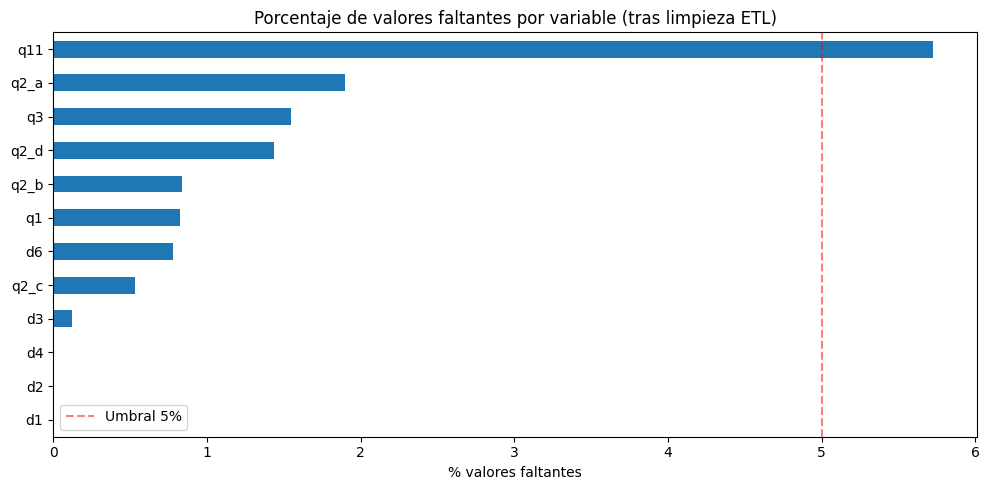


Resumen de nulos por variable:
q11     5.72
q2_a    1.90
q3      1.55
q2_d    1.44
q2_b    0.84
q1      0.82
d6      0.78
q2_c    0.53
d3      0.12
d1      0.00
d2      0.00
d4      0.00
dtype: float64


In [ ]:
# =========================================================
# 4B. VISUALIZACIÓN DE VALORES FALTANTES (ETL)
# =========================================================

cols_visualizar = ['q1','q2_a','q2_b','q2_c','q2_d','q3','q11','d1','d2','d3','d4','d6']
cols_visualizar = [c for c in cols_visualizar if c in df.columns]

pct_nulos = df[cols_visualizar].isnull().mean() * 100

plt.figure(figsize=(10, 5))
pct_nulos.sort_values(ascending=True).plot(kind='barh')
plt.title("Porcentaje de valores faltantes por variable (tras limpieza ETL)")
plt.xlabel("% valores faltantes")
plt.axvline(x=5, color='red', linestyle='--', alpha=0.5, label='Umbral 5%')
plt.legend()
plt.tight_layout()
plt.savefig(f"{output_dir}/nulos_tras_limpieza.png", bbox_inches="tight")
plt.show()

print("\nResumen de nulos por variable:")
print(pct_nulos.round(2).sort_values(ascending=False))

RECODIFICACIÓN DE ESCALAS: 4 = muy importante / 1 = nada importante. Así es más fácil la interpretación.

In [ ]:
# =========================================================
# 5. RECODIFICACIÓN DE ESCALAS q2
# =========================================================
# Documentación:
# q2_a = impacto ambiental
# q2_b = precio
# q2_c = calidad
# q2_d = marca

mapa_invertido = {
    1: 4,
    2: 3,
    3: 2,
    4: 1
}

for col in ['q2_a', 'q2_b', 'q2_c', 'q2_d']:
    if col in df.columns:
        df[col + '_recod'] = df[col].map(mapa_invertido)

print("\nEjemplo recodificación:")
print(df[['q2_a', 'q2_a_recod', 'q2_b', 'q2_b_recod', 'q2_c', 'q2_c_recod', 'q2_d', 'q2_d_recod']].head())


Ejemplo recodificación:
   q2_a  q2_a_recod  q2_b  q2_b_recod  q2_c  q2_c_recod  q2_d  q2_d_recod
0   2.0         3.0   4.0         1.0   4.0         1.0   2.0         3.0
1   3.0         2.0   4.0         1.0   3.0         2.0   2.0         3.0
2   3.0         2.0   2.0         3.0   3.0         2.0   2.0         3.0
3   4.0         1.0   4.0         1.0   4.0         1.0   2.0         3.0
4   3.0         2.0   3.0         2.0   3.0         2.0   2.0         3.0


VARIABLE OBJETIVO CORRECTA: la he construido a partir de la variable q2_a= importancia del impacto medioambiental. Para facilitar la interpretación he invertido la escala y he eliminado los valores de no respesta. Después la he definido como "orietación_sosteinble" para que refleje el el grado de preocupaciónn ambiental de los individuos en sus decisiones de compraa, por lo tanto es una variable que mida la actitud hacia el consumo sostenible.

In [ ]:
# =========================================================
# 6. VARIABLE OBJETIVO CORRECTA
# =========================================================
# q2_a = importancia del impacto ambiental
# Se usa como proxy de orientación sostenible

df['orientacion_sostenible'] = df['q2_a_recod']

print("\nDistribución de orientacion_sostenible:")
print(df['orientacion_sostenible'].value_counts(dropna=False).sort_index())


Distribución de orientacion_sostenible:
orientacion_sostenible
1.0     9709
2.0    12313
3.0     3070
4.0     1044
NaN      506
Name: count, dtype: int64


EDAD REAL A PARTIR DE LA VARIABLE D2: como resultado he obtenido una media de edad de 50 años, de este modo he eliminado las edades menores a 15 y los errores.

In [ ]:
# =========================================================
# 7. EDAD REAL A PARTIR DE D2
# =========================================================
# d2 = edad exacta del entrevistado

if 'd2' in df.columns:
    df['edad'] = pd.to_numeric(df['d2'], errors='coerce')

    print("\nEstadísticos de edad antes de limpiar:")
    print(df['edad'].describe())

    # edades válidas
    df.loc[(df['edad'] < 15) | (df['edad'] > 99), 'edad'] = np.nan

    print("\nEstadísticos de edad después de limpiar:")
    print(df['edad'].describe())


Estadísticos de edad antes de limpiar:
count    26642.000000
mean        49.576571
std         17.917272
min          0.000000
25%         37.000000
50%         51.000000
75%         63.000000
max         99.000000
Name: edad, dtype: float64

Estadísticos de edad después de limpiar:
count    26389.000000
mean        50.051878
std         17.329618
min         15.000000
25%         37.000000
50%         51.000000
75%         63.000000
max         99.000000
Name: edad, dtype: float64


VARIABLE EDUCATIVA (A PARTIR DE D3): he transformado d3( edad en la que dejaron de estudiar) en categorías:
- bajo= 7467 (la más frecuente)
- medio-bajo
- medio
- medio-alto
- alto
Esta distribución muestra una concentración en niveles educativos intermedios (coherene con la estructura educativa en europa)


In [ ]:
# =========================================================
# 8. VARIABLE EDUCATIVA A PARTIR DE D3
# =========================================================
# d3 = edad a la que dejó la educación a tiempo completo

if 'd3' in df.columns:
    df['fin_estudios'] = pd.to_numeric(df['d3'], errors='coerce')

    df.loc[(df['fin_estudios'] < 10) | (df['fin_estudios'] > 40), 'fin_estudios'] = np.nan

    def clasificar_educacion(x):
        if pd.isna(x):
            return np.nan
        elif x <= 15:
            return "Bajo"
        elif x <= 18:
            return "Medio-bajo"
        elif x <= 21:
            return "Medio"
        elif x <= 24:
            return "Medio-alto"
        else:
            return "Alto"

    df['nivel_educativo'] = df['fin_estudios'].apply(clasificar_educacion)

    print("\nDistribución nivel_educativo:")
    print(df['nivel_educativo'].value_counts(dropna=False))


Distribución nivel_educativo:
nivel_educativo
Medio-bajo    7467
Medio         5350
Medio-alto    4041
Bajo          3556
NaN           3194
Alto          3034
Name: count, dtype: int64


ORIENTACIÓN SOSTENIBLE POR SEXO:

*   mujeres: categorías 1 y 2
*   hombres: ligeramente menos sosteibles

* HAY MAS MUJERES EN EL DATASET POR ESO NO CUADRA CON EL GRÁFICO. HACEMOS CASO AL GRÁFICO



In [ ]:
# =========================================================
# 9. ORIENTACIÓN SOSTENIBLE POR SEXO
# =========================================================

print("\nDistribución por sexo:")
if 'd1' in df.columns:
    print(df['d1'].value_counts(dropna=False).sort_index())

print("\nOrientación sostenible por sexo:")
if 'd1' in df.columns:
    print(pd.crosstab(df['d1'], df['orientacion_sostenible']))


Distribución por sexo:
d1
1     9940
2    16702
Name: count, dtype: int64

Orientación sostenible por sexo:
orientacion_sostenible   1.0   2.0   3.0  4.0
d1                                           
1                       3146  4715  1425  473
2                       6563  7598  1645  571


ORIENTACIÓN SOSTEIBLE POR NIVEL EDUCATIVO: vemos un patrón claro. A edida que aumenta el nivel educativo disminuye ligeramente la proporción de individuos que consideran el impacto ambiental como nada importante, y aumenta la presencia de niveles intermedios y altos de preocupación.

In [ ]:
# =========================================================
# 10. ORIENTACIÓN SOSTENIBLE POR NIVEL EDUCATIVO
# =========================================================

if 'nivel_educativo' in df.columns:
    print("\nOrientación sostenible por nivel educativo:")
    print(pd.crosstab(df['nivel_educativo'], df['orientacion_sostenible']))


Orientación sostenible por nivel educativo:
orientacion_sostenible   1.0   2.0  3.0  4.0
nivel_educativo                             
Alto                    1106  1495  307   98
Bajo                    1515  1384  351  181
Medio                   1915  2595  572  189
Medio-alto              1481  1997  427   92
Medio-bajo              2714  3407  904  296


GRÁFICO ORIETACIÓN SOSTENIBLE (%) POR NIVEL EDUCATIVO: Observamos como el nivel educativo presenta una relación positiva, aunque débil, con la orientación sostenible.


Orientación sostenible (%) por nivel educativo:
orientacion_sostenible      1      2      3     4
nivel_educativo                                  
Alto                    36.79  49.73  10.21  3.26
Bajo                    44.16  40.34  10.23  5.28
Medio                   36.33  49.23  10.85  3.59
Medio-alto              37.05  49.96  10.68  2.30
Medio-bajo              37.07  46.54  12.35  4.04


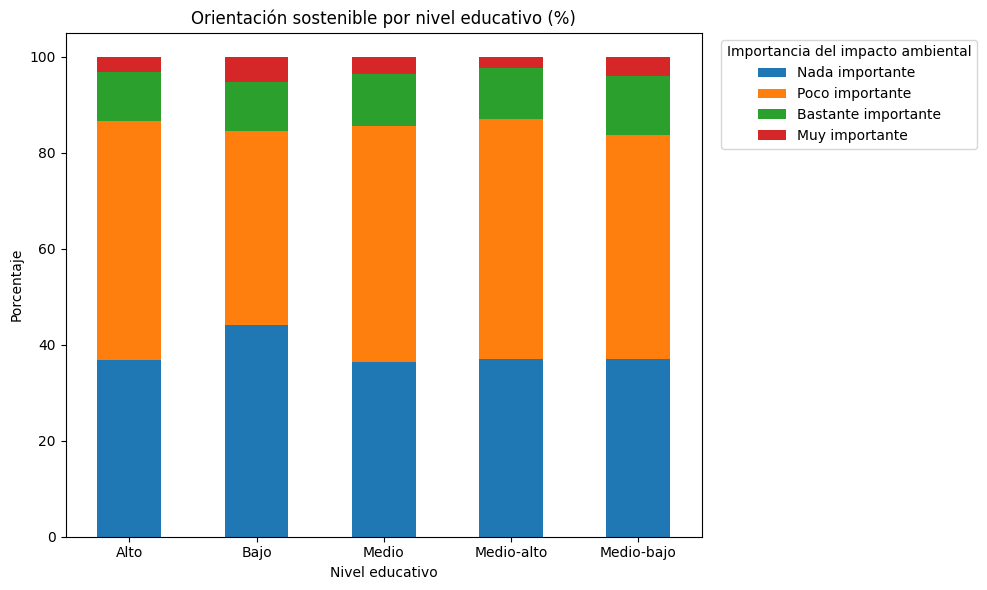

In [ ]:
# =========================================================
# 11. ORIENTACIÓN SOSTENIBLE (%) POR NIVEL EDUCATIVO
# =========================================================

if 'nivel_educativo' in df.columns:
    tabla_pct = pd.crosstab(
        df['nivel_educativo'],
        df['orientacion_sostenible'],
        normalize='index'
    ) * 100

    tabla_pct = tabla_pct.reindex(columns=[1, 2, 3, 4])

    print("\nOrientación sostenible (%) por nivel educativo:")
    print(tabla_pct.round(2))

    tabla_pct_bonita = tabla_pct.copy()
    tabla_pct_bonita.columns = [
        "Nada importante",
        "Poco importante",
        "Bastante importante",
        "Muy importante"
    ]

    tabla_pct_bonita.plot(kind='bar', stacked=True, figsize=(10, 6))
    plt.title("Orientación sostenible por nivel educativo (%)")
    plt.xlabel("Nivel educativo")
    plt.ylabel("Porcentaje")
    plt.xticks(rotation=0)
    plt.legend(title="Importancia del impacto ambiental", bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(f"{output_dir}/grafico_nivel_educativo_bonito.png", bbox_inches="tight")
    plt.show()

GRÁFICO DISTRIBUCIÓN GENERAL DE ORIENTACIÓN SOSTENIBLE: con este gráfico observamos que la mayoría de la población en Europa tiene una baja orientación sostenible en términos generales.

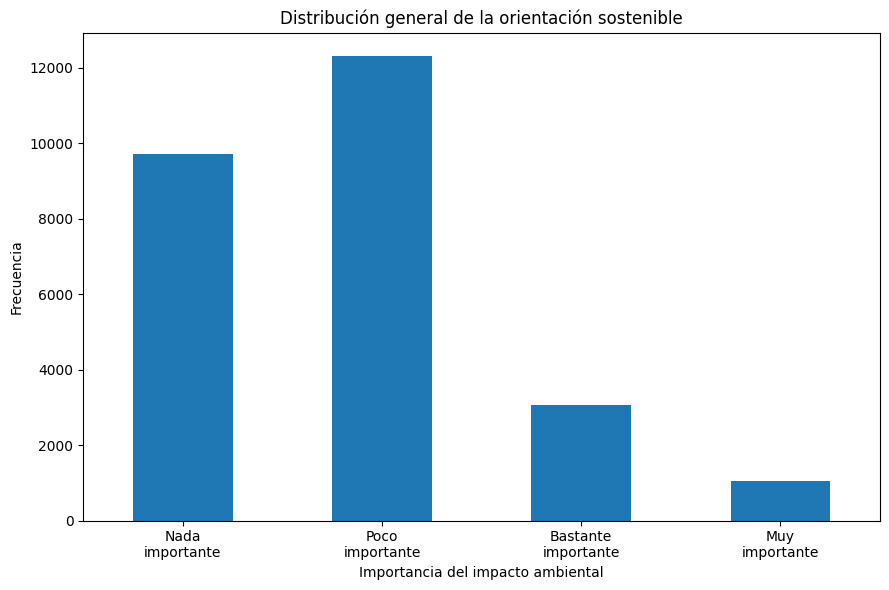

In [ ]:
# =========================================================
# 12. DISTRIBUCIÓN GENERAL DE ORIENTACIÓN SOSTENIBLE
# =========================================================

conteo_sost = df['orientacion_sostenible'].value_counts().sort_index()
conteo_sost = conteo_sost.reindex([1, 2, 3, 4])

conteo_sost.index = [
    "Nada\nimportante",
    "Poco\nimportante",
    "Bastante\nimportante",
    "Muy\nimportante"
]

conteo_sost.plot(kind='bar', figsize=(9, 6))
plt.title("Distribución general de la orientación sostenible")
plt.xlabel("Importancia del impacto ambiental")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{output_dir}/distribucion_sostenibilidad_bonita.png", bbox_inches="tight")
plt.show()

GRÁFICO ORIENTACIÓN SOSTENIBLE PR SEXO (%): no se observan diferencias significativas entre hombres y mujeres.

*   muchos estudios dicen lo contrario.COMENTARLO EN REDACCIÓN TFG




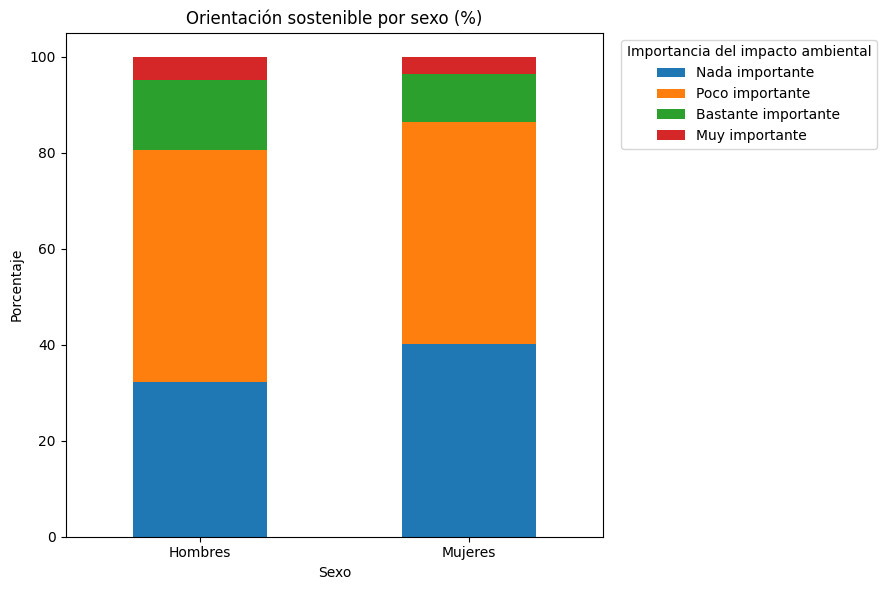

In [ ]:
# =========================================================
# 13. ORIENTACIÓN SOSTENIBLE POR SEXO (%)
# =========================================================

tabla_sexo_pct = pd.crosstab(
    df['d1'],
    df['orientacion_sostenible'],
    normalize='index'
) * 100

tabla_sexo_pct = tabla_sexo_pct.reindex(columns=[1, 2, 3, 4])

if len(tabla_sexo_pct.index) == 2:
    tabla_sexo_pct.index = ["Hombres", "Mujeres"]

tabla_sexo_pct.columns = [
    "Nada importante",
    "Poco importante",
    "Bastante importante",
    "Muy importante"
]

tabla_sexo_pct.plot(kind='bar', stacked=True, figsize=(9, 6))
plt.title("Orientación sostenible por sexo (%)")
plt.xlabel("Sexo")
plt.ylabel("Porcentaje")
plt.xticks(rotation=0)
plt.legend(title="Importancia del impacto ambiental", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"{output_dir}/grafico_sexo_bonito.png", bbox_inches="tight")
plt.show()

GRÁFICO PRECIO VS SOSTENIBILIDAD (%): cuando el precio es "muy importante", sube "nada importante" de ambiental. Por lo tanto, existe una relación inversa entre la importancia del precio y la orientación sostenible. *barrera económica a la sostenibilidad

*   barrera económica a la sostenibilidad




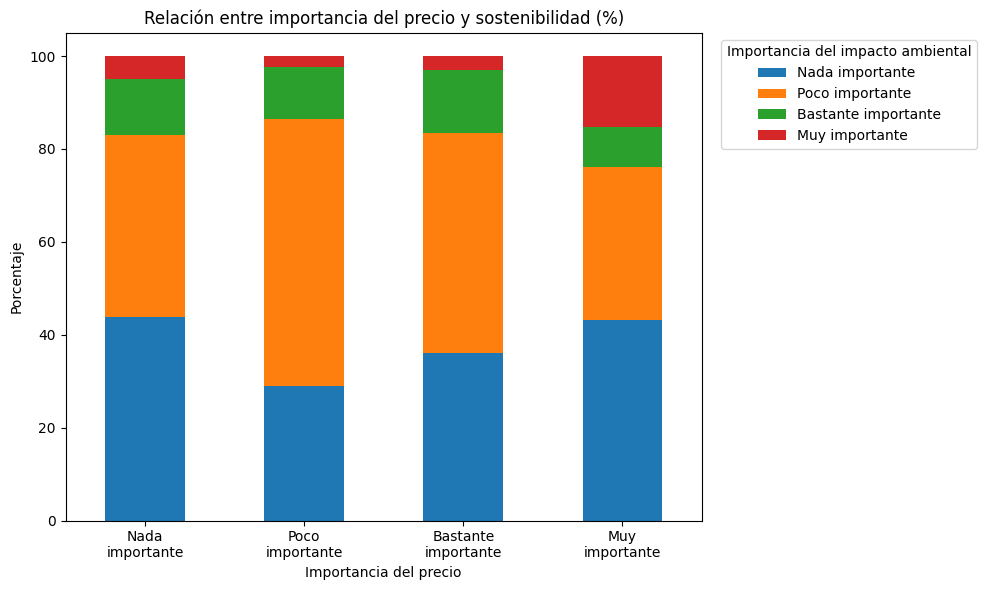

In [ ]:
# =========================================================
# 14. PRECIO VS SOSTENIBILIDAD (%)
# =========================================================

tabla_precio = pd.crosstab(
    df['q2_b_recod'],
    df['orientacion_sostenible'],
    normalize='index'
) * 100

tabla_precio = tabla_precio.reindex(index=[1, 2, 3, 4], columns=[1, 2, 3, 4])

tabla_precio.index = [
    "Nada\nimportante",
    "Poco\nimportante",
    "Bastante\nimportante",
    "Muy\nimportante"
]

tabla_precio.columns = [
    "Nada importante",
    "Poco importante",
    "Bastante importante",
    "Muy importante"
]

tabla_precio.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title("Relación entre importancia del precio y sostenibilidad (%)")
plt.xlabel("Importancia del precio")
plt.ylabel("Porcentaje")
plt.xticks(rotation=0)
plt.legend(title="Importancia del impacto ambiental", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"{output_dir}/grafico_precio_sostenibilidad_bonito.png", bbox_inches="tight")
plt.show()

GRÁFICO ECOETIQUETAS Y SOSTENIBILIDAD (%): Cuanto más iportantes son sube. Las ecoetiquetas funcionan, por lo que influyen en el comportaiento y se asocia positivamente con una mayor orientación sostenible.

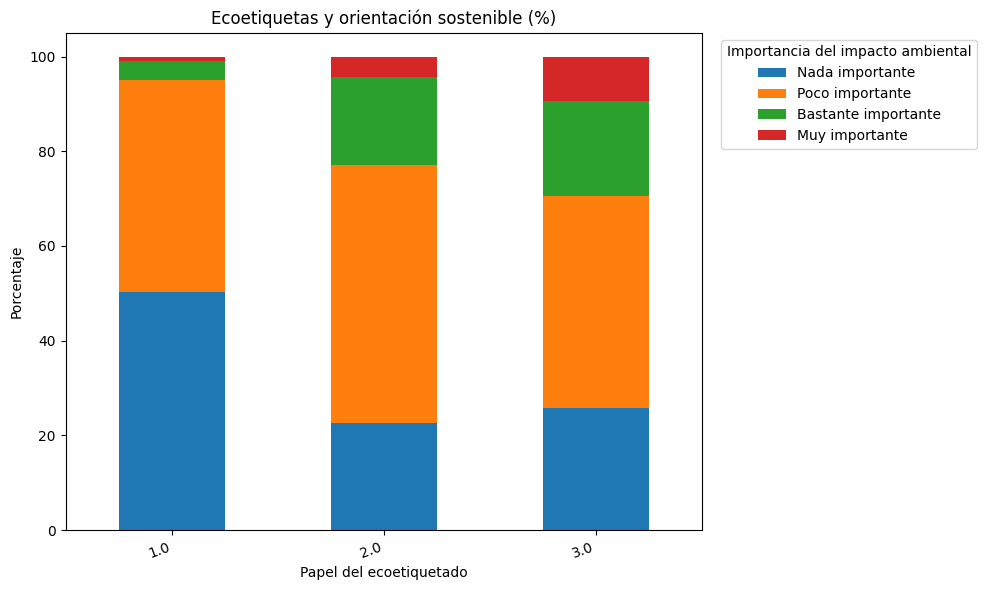

In [ ]:
# =========================================================
# 15. ECOETIQUETAS Y SOSTENIBILIDAD (%)
# =========================================================

tabla_eco = pd.crosstab(
    df['q3'],
    df['orientacion_sostenible'],
    normalize='index'
) * 100

tabla_eco = tabla_eco.reindex(columns=[1, 2, 3, 4])

tabla_eco.columns = [
    "Nada importante",
    "Poco importante",
    "Bastante importante",
    "Muy importante"
]

tabla_eco.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title("Ecoetiquetas y orientación sostenible (%)")
plt.xlabel("Papel del ecoetiquetado")
plt.ylabel("Porcentaje")
plt.xticks(rotation=20, ha='right')
plt.legend(title="Importancia del impacto ambiental", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"{output_dir}/grafico_ecoetiquetas_bonito.png", bbox_inches="tight")
plt.show()

GRÁICO CREDIBILIDAD DE INFORMES EMPRESARIALES Y SOSTENIBILIDAD (%): Podemos ver como la confianza es clave. A mayor confianza más sostenibilidad.

*   PROBLEMA DEL GREENWHAING (si no confían no compran verde)


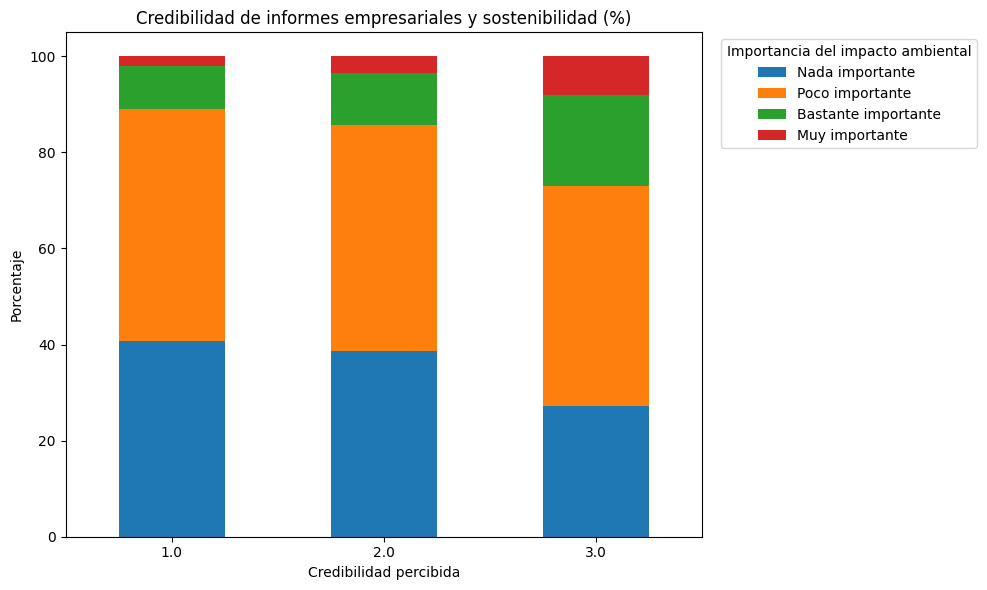

In [ ]:
# =========================================================
# 16. CREDIBILIDAD DE INFORMES EMPRESARIALES Y SOSTENIBILIDAD (%)
# =========================================================

tabla_confianza = pd.crosstab(
    df['q11'],
    df['orientacion_sostenible'],
    normalize='index'
) * 100

tabla_confianza = tabla_confianza.reindex(columns=[1, 2, 3, 4])

tabla_confianza.columns = [
    "Nada importante",
    "Poco importante",
    "Bastante importante",
    "Muy importante"
]

tabla_confianza.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title("Credibilidad de informes empresariales y sostenibilidad (%)")
plt.xlabel("Credibilidad percibida")
plt.ylabel("Porcentaje")
plt.xticks(rotation=0)
plt.legend(title="Importancia del impacto ambiental", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"{output_dir}/grafico_confianza_empresas_bonito.png", bbox_inches="tight")
plt.show()

GRÁFICO IMPORTANCIA MEDIA DE FACTORES DE COMPRA: Orden:
1.  marca
2. impacto ambiental
3. precio
4. calidad
La marca es el factor más relevante en la decisión de compra, incluso superando al impacto ambiental.
* EL CONSUMIDOR NO ES RACIONAL ECOLOGICO, ES EMOCIONAL (MARCA)



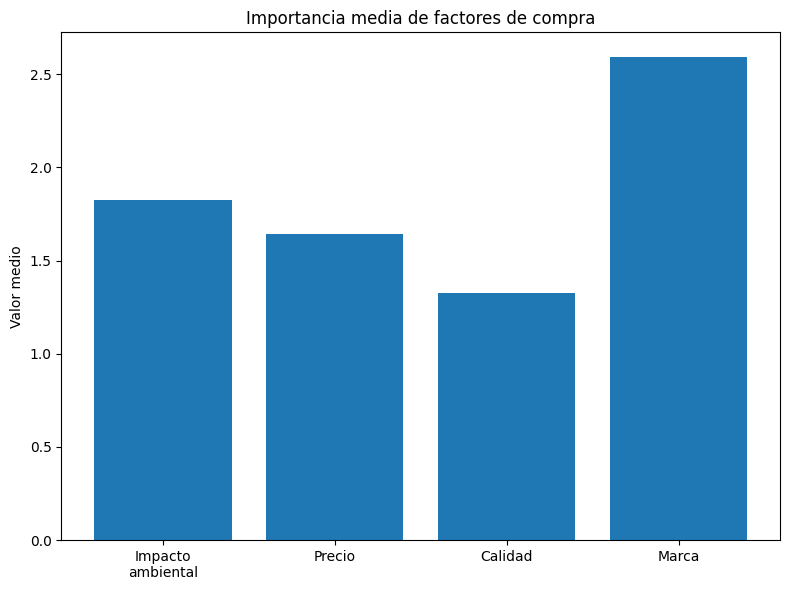

In [ ]:
# =========================================================
# 17. IMPORTANCIA MEDIA DE FACTORES DE COMPRA
# =========================================================

factores = ['q2_a_recod', 'q2_b_recod', 'q2_c_recod', 'q2_d_recod']
nombres = ['Impacto\nambiental', 'Precio', 'Calidad', 'Marca']

medias = [df[f].mean() for f in factores]

plt.figure(figsize=(8, 6))
plt.bar(nombres, medias)
plt.title("Importancia media de factores de compra")
plt.ylabel("Valor medio")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{output_dir}/grafico_factores_compra_bonito.png", bbox_inches="tight")
plt.show()

He transforando la varyable country a sus correspondidos nombres de país usando la codificación oficial del estudio

In [ ]:
# =========================================================
# MAPEO OFICIAL DE COUNTRY SEGÚN GESIS + COMPROBACIÓN
# =========================================================

country_map = {
    1: "Francia",
    2: "Bélgica",
    3: "Países Bajos",
    4: "Alemania",
    5: "Italia",
    6: "Luxemburgo",
    7: "Dinamarca",
    8: "Irlanda",
    9: "Reino Unido",
    11: "Grecia",
    12: "España",
    13: "Portugal",
    16: "Finlandia",
    17: "Suecia",
    18: "Austria",
    19: "Chipre",
    20: "República Checa",
    21: "Estonia",
    22: "Hungría",
    23: "Letonia",
    24: "Lituania",
    25: "Malta",
    26: "Polonia",
    27: "Eslovaquia",
    28: "Eslovenia",
    29: "Bulgaria",
    30: "Rumanía",
    32: "Croacia"
}

df['country_name'] = df['country'].map(country_map)

codigos_presentes = sorted(df['country'].dropna().unique().tolist())
codigos_sin_mapear = sorted([c for c in codigos_presentes if c not in country_map])

print("Códigos presentes en el dataset:", codigos_presentes)

if codigos_sin_mapear:
    raise ValueError(f"Hay códigos de país sin mapear: {codigos_sin_mapear}")
else:
    print("Todos los códigos de país presentes están correctamente mapeados.")

Códigos presentes en el dataset: [1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 32]
Todos los códigos de país presentes están correctamente mapeados.


Con esta tabla auxiliar he ordenado los países segun la media de su nivel general de sostenibilidad.
Podemos observar que los paises del norte de Europa (Dinamarca, Suecia, Alemania, Francia, Finlandia) dominan claramente frente el este y sur de Europa ( Rumnanía, Bulgaria, Malta; Polonia) que presentan una menos orientación sostenible.
* esto se puede deber a q los países del este y sur de europa tienen menor desarrollo económico, menor conciencia ambiental, y menor presión institucional

In [ ]:
# =========================================================
# TABLA AUXILIAR: MEDIA DE SOSTENIBILIDAD POR PAÍS
# =========================================================

media_pais = df.groupby('country_name')['orientacion_sostenible'].mean().sort_values(ascending=False)

print("\nMedia de orientación sostenible por país:")
print(media_pais.round(3))


Media de orientación sostenible por país:
country_name
Finlandia          2.116
República Checa    2.086
Letonia            2.044
Estonia            2.029
Eslovaquia         1.947
Suecia             1.925
Reino Unido        1.922
Bulgaria           1.916
Países Bajos       1.903
Dinamarca          1.900
Lituania           1.879
Francia            1.854
Croacia            1.845
Polonia            1.826
Portugal           1.823
Alemania           1.811
España             1.808
Hungría            1.798
Irlanda            1.785
Malta              1.728
Luxemburgo         1.693
Bélgica            1.680
Italia             1.651
Eslovenia          1.648
Rumanía            1.615
Austria            1.612
Grecia             1.523
Chipre             1.486
Name: orientacion_sostenible, dtype: float64


GRÁFICO ORIENTACIÓN SOSTENIBLE POR PAIS (%): Vemos diferencias claras entre países. La sosteibilidad depende del contexto, de la influenciaa de factores culturales, económicos e institucionales.

*   Dinamarca o Suecia = alta proporción de "bastante importanet"
*   Rumanía o Bulgaria = mucho mas peso en " nada importante"




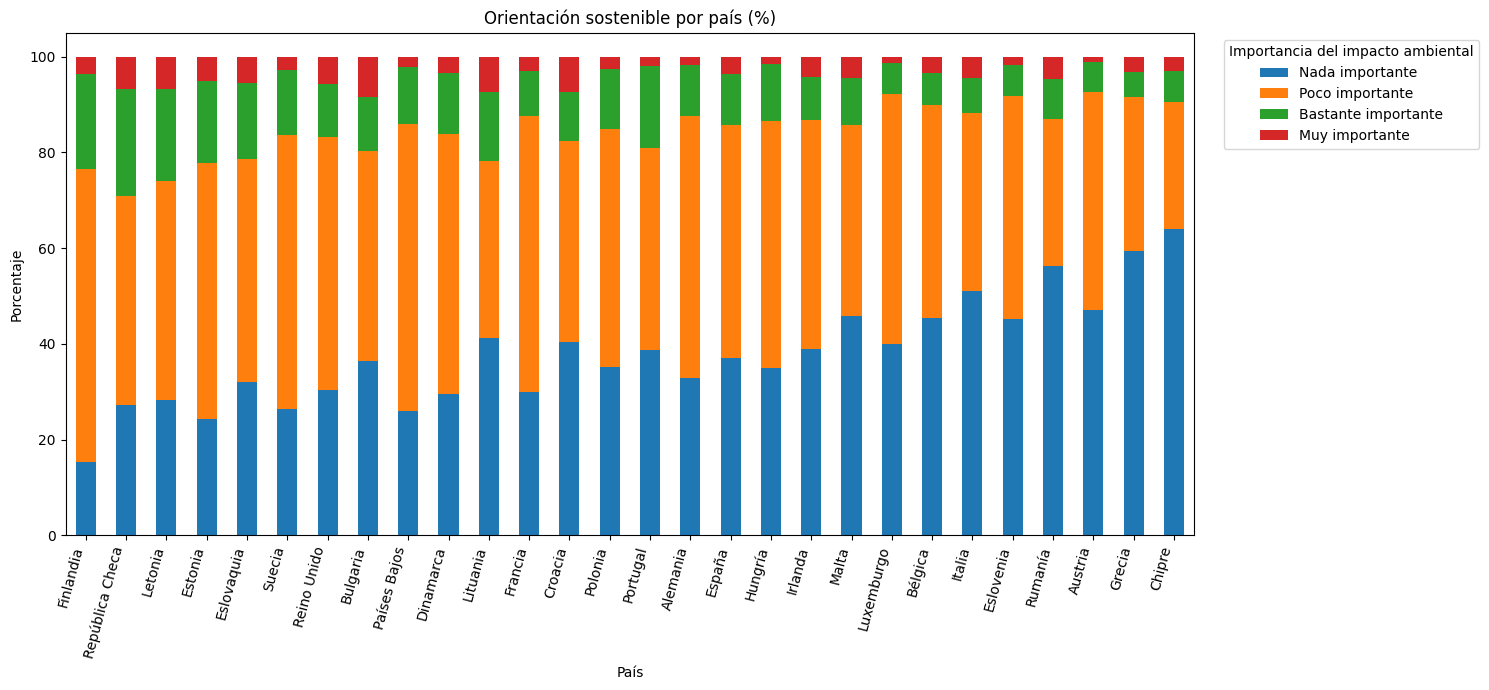

In [ ]:
# =========================================================
# 18. ORIENTACIÓN SOSTENIBLE POR PAÍS (%) ORDENADA
# =========================================================

tabla_pais = pd.crosstab(
    df['country_name'],
    df['orientacion_sostenible'],
    normalize='index'
) * 100

tabla_pais = tabla_pais.reindex(columns=[1, 2, 3, 4])

tabla_pais.columns = [
    "Nada importante",
    "Poco importante",
    "Bastante importante",
    "Muy importante"
]

# Ordenar países según la media de orientación sostenible
orden_paises = media_pais.index
tabla_pais = tabla_pais.loc[orden_paises]

tabla_pais.plot(kind='bar', stacked=True, figsize=(15, 7))

plt.title("Orientación sostenible por país (%)")
plt.xlabel("País")
plt.ylabel("Porcentaje")
plt.xticks(rotation=75, ha='right')
plt.legend(
    title="Importancia del impacto ambiental",
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.savefig(f"{output_dir}/grafico_pais_bonito_ordenado.png", bbox_inches="tight")
plt.show()

GRÁFICO ORIENTACIÓN SOSTENIBLE POR PAÍS (TOP 10): Podemos relacionar la mayor orientación sostenible con mayores niveles de desarrollo, políticas ambientales o conciencia social de los países.

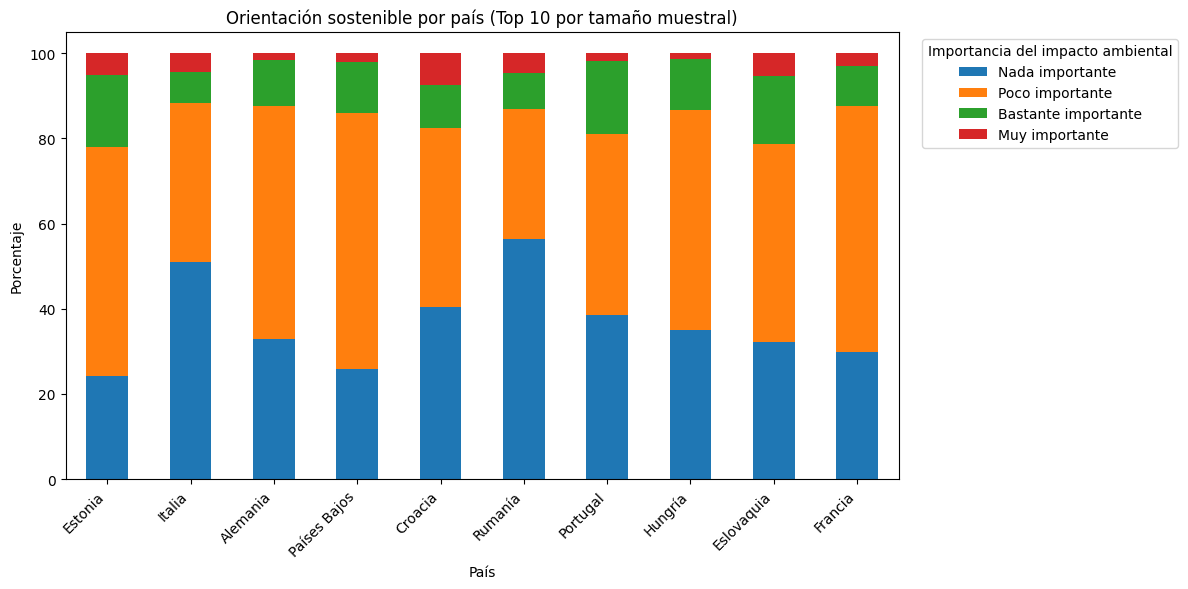

In [ ]:
# =========================================================
# 19. ORIENTACIÓN SOSTENIBLE POR PAÍS (TOP 10 POR MUESTRA)
# =========================================================

top_paises = df['country_name'].value_counts().head(10).index
df_top = df[df['country_name'].isin(top_paises)].copy()

tabla_pais_top = pd.crosstab(
    df_top['country_name'],
    df_top['orientacion_sostenible'],
    normalize='index'
) * 100

tabla_pais_top = tabla_pais_top.reindex(columns=[1, 2, 3, 4])

tabla_pais_top.columns = [
    "Nada importante",
    "Poco importante",
    "Bastante importante",
    "Muy importante"
]

# Mantener orden por frecuencia muestral
tabla_pais_top = tabla_pais_top.loc[top_paises]

tabla_pais_top.plot(kind='bar', stacked=True, figsize=(12, 6))

plt.title("Orientación sostenible por país (Top 10 por tamaño muestral)")
plt.xlabel("País")
plt.ylabel("Porcentaje")
plt.xticks(rotation=45, ha='right')
plt.legend(
    title="Importancia del impacto ambiental",
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.savefig(f"{output_dir}/grafico_paises_top10_muestra.png", bbox_inches="tight")
plt.show()

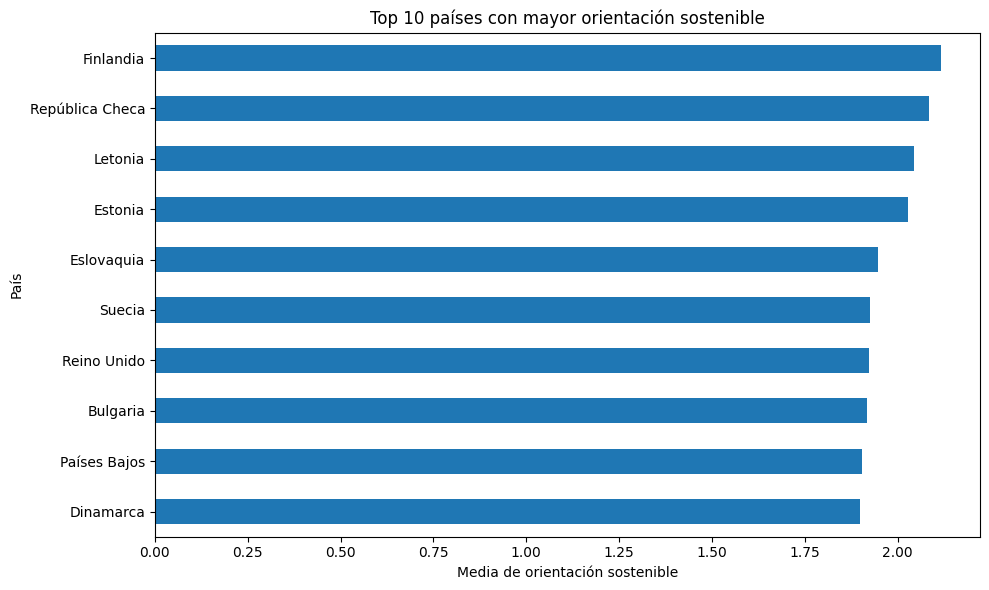

In [ ]:
# =========================================================
# 19B. TOP 10 PAÍSES CON MAYOR MEDIA DE SOSTENIBILIDAD
# =========================================================

top10_sostenibles = media_pais.head(10).sort_values()

plt.figure(figsize=(10, 6))
top10_sostenibles.plot(kind='barh')

plt.title("Top 10 países con mayor orientación sostenible")
plt.xlabel("Media de orientación sostenible")
plt.ylabel("País")

plt.tight_layout()
plt.savefig(f"{output_dir}/top10_paises_mas_sostenibles.png", bbox_inches="tight")
plt.show()

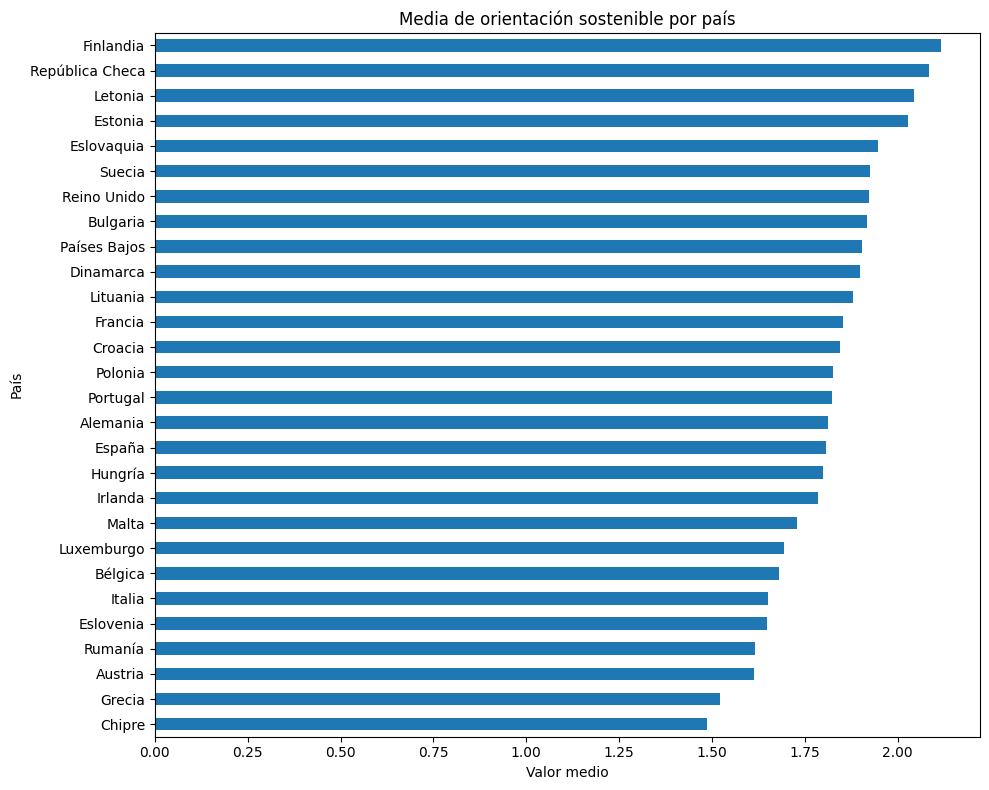

In [ ]:
# =========================================================
# 20. MEDIA DE ORIENTACIÓN SOSTENIBLE POR PAÍS
# =========================================================

media_pais_asc = media_pais.sort_values()

plt.figure(figsize=(10, 8))
media_pais_asc.plot(kind='barh')

plt.title("Media de orientación sostenible por país")
plt.xlabel("Valor medio")
plt.ylabel("País")

plt.tight_layout()
plt.savefig(f"{output_dir}/media_sostenibilidad_pais.png", bbox_inches="tight")
plt.show()

Esta tabla nos muestra que casi todos los países tienen alrededor de 1000 observaciones (algunos más peqeños como Luxemburgo, Malta o Chipre tienen alrededor de 500), lo que significa que el datset está muy equilibrado y no existen sesgos fuertes por tamaño de muestra

In [ ]:
# =========================================================
# TABLA RESUMEN DE PAÍSES
# =========================================================

tabla_resumen_paises = pd.DataFrame({
    'n_muestra': df['country_name'].value_counts(),
    'media_sostenibilidad': df.groupby('country_name')['orientacion_sostenible'].mean()
}).sort_values(by='media_sostenibilidad', ascending=False)

print("\nTabla resumen de países:")
print(tabla_resumen_paises.round(3))

tabla_resumen_paises.to_csv(f"{output_dir}/tabla_resumen_paises.csv")


Tabla resumen de países:
                 n_muestra  media_sostenibilidad
country_name                                    
Finlandia             1000                 2.116
República Checa       1002                 2.086
Letonia               1005                 2.044
Estonia               1015                 2.029
Eslovaquia            1007                 1.947
Suecia                1000                 1.925
Reino Unido           1001                 1.922
Bulgaria              1004                 1.916
Países Bajos          1010                 1.903
Dinamarca             1000                 1.900
Lituania              1005                 1.879
Francia               1006                 1.854
Croacia               1009                 1.845
Polonia               1005                 1.826
Portugal              1009                 1.823
Alemania              1010                 1.811
España                1002                 1.808
Hungría               1007                 

HISTOGRAMA DISTRIBUCIÓN DE EDAD: vamos que hay una mayor ocncentración entre 40 y 65 años, y una media alrededor de los 50 (ya lo habíamos visto antes). Hay poco jovenes (menos de 25) y pocos muy mayores (mayores de 80).
Esta muestra no esta equilibrada ya que el comportamiento sostenible puede depender de la edad y esta muestra está "envejecida".
* como hay poca presencia de individuos jóvenes puede influir en los resultados de los análisis.

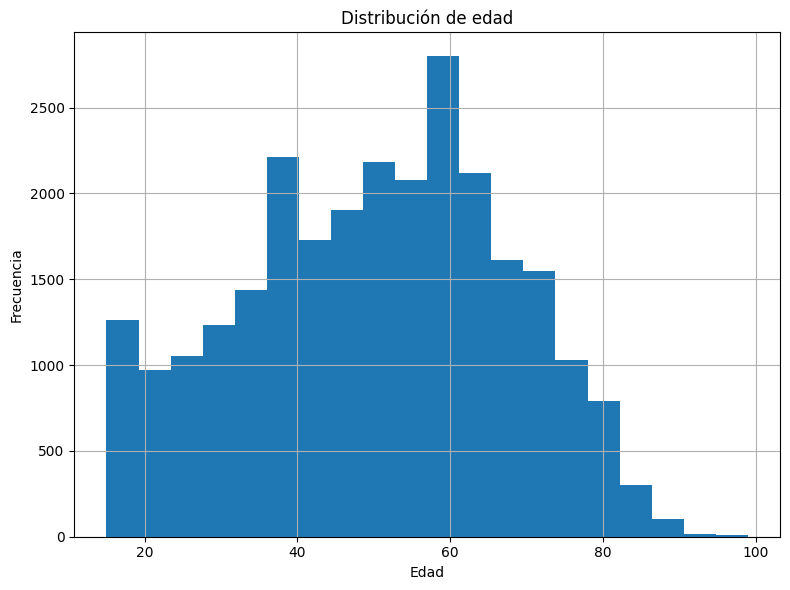

In [ ]:
# =========================================================
# 21. DISTRIBUCIÓN DE EDAD
# =========================================================

plt.figure(figsize=(8, 6))
df['edad'].dropna().hist(bins=20)
plt.title("Distribución de edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig(f"{output_dir}/histograma_edad.png")
plt.show()

BOXPLOT EDAD VS SOSTENIBILIDAD:

NIVEL 1= MEDIANA: 54 AÑOS
NIVEL 2= 49
NIVEL 3= 44
NIVEL 4= 50

* Los más sostenibles (3y4) tieden a ser más jovenes.
* Los menos sosteibles (nivel 1) son más mayores
* Niveñl 4 no sigue un patrón perfecto por lo que la relación es no lineal perfecta

* la relación no es completamente lineal, lo que indica que la edad no actúa como un factor determinante único.



<Figure size 800x600 with 0 Axes>

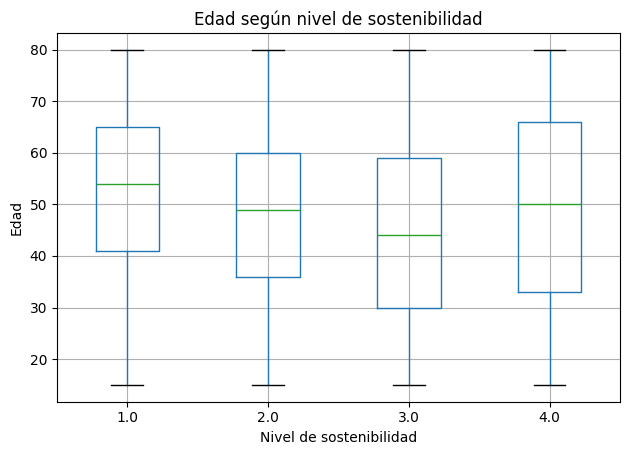

In [ ]:
# =========================================================
# 22. BOXPLOT EDAD VS SOSTENIBILIDAD
# =========================================================

df_box = df[(df['edad'] >= 15) & (df['edad'] <= 80)].copy()

plt.figure(figsize=(8, 6))
df_box.boxplot(
    column='edad',
    by='orientacion_sostenible',
    showfliers=False
)
plt.title("Edad según nivel de sostenibilidad")
plt.suptitle("")
plt.xlabel("Nivel de sostenibilidad")
plt.ylabel("Edad")
plt.tight_layout()
plt.savefig(f"{output_dir}/boxplot_edad_sostenibilidad.png")
plt.show()

GRÁFICO GRUPOS DE EDAD Y SOSTEBILIDAD: Resultado:

*   menores de 25 = 2.08
*   25 - 40 = 1.91
*   40 - 60 = 1.78
*   Myore de 60 = 1.74

- A más edad menor sostenibilidad



/tmp/ipykernel_1438/3045210980.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  media_edad = df.groupby('grupo_edad')['orientacion_sostenible'].mean()


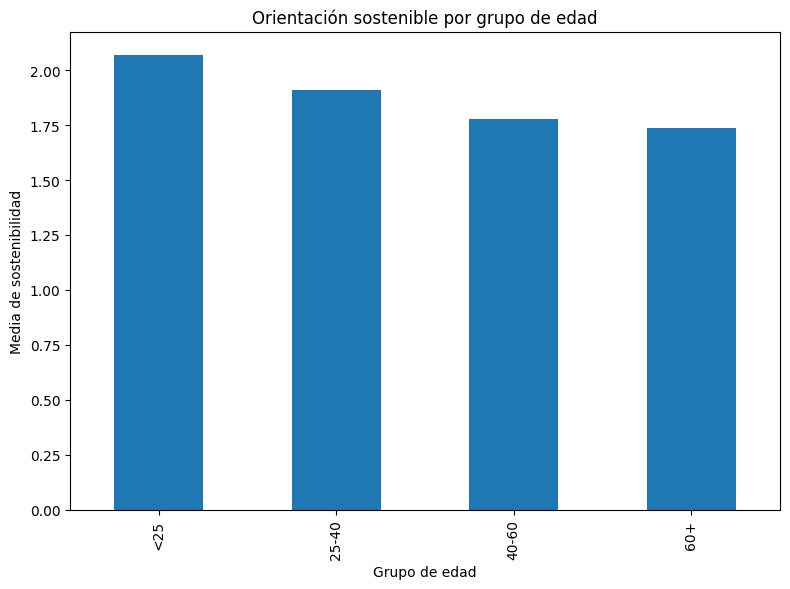

In [ ]:
# =========================================================
# 23. GRUPOS DE EDAD Y SOSTENIBILIDAD
# =========================================================

bins_edad = [15, 25, 40, 60, 80]
labels_edad = ["<25", "25-40", "40-60", "60+"]

df['grupo_edad'] = pd.cut(df['edad'], bins=bins_edad, labels=labels_edad)

media_edad = df.groupby('grupo_edad')['orientacion_sostenible'].mean()

plt.figure(figsize=(8, 6))
media_edad.plot(kind='bar')
plt.title("Orientación sostenible por grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Media de sostenibilidad")
plt.tight_layout()
plt.savefig(f"{output_dir}/sostenibilidad_por_edad.png")
plt.show()

MATRIZ DE CORRELACIÓN: (orientacion_sostenible = q2_a por eso correlación es 1 )
RELACIONES IMPORTANTES:
*   q3(ecoetiquetas) =  0.32: relación positiva moderada. Más importancia a ecoetiquetas, más sostenibilidad.
*   q2_c(calidad) = 0.23: relación débil-moderada
*   q2_d(marca) = 0.11: relación débil
*   edad = -0.14: relación negativa. Más edad, menos sostenibilidad

* NINGUNA VARIABLE EXPLICA BIEN LA SOSTENIBILIDAD (las relaciones son debiles). EL COMPORTAMIENTO ES COMPLEJO




Matriz de correlación:
                        q2_a_recod  q2_b_recod  q2_c_recod  q2_d_recod    q3  \
q2_a_recod                    1.00        0.08        0.23        0.11  0.32   
q2_b_recod                    0.08        1.00        0.23        0.10 -0.08   
q2_c_recod                    0.23        0.23        1.00        0.15  0.09   
q2_d_recod                    0.11        0.10        0.15        1.00  0.07   
q3                            0.32       -0.08        0.09        0.07  1.00   
q11                           0.13       -0.04        0.02        0.03  0.20   
edad                         -0.14       -0.07       -0.05       -0.05 -0.04   
orientacion_sostenible        1.00        0.08        0.23        0.11  0.32   

                         q11  edad  orientacion_sostenible  
q2_a_recod              0.13 -0.14                    1.00  
q2_b_recod             -0.04 -0.07                    0.08  
q2_c_recod              0.02 -0.05                    0.23  
q2_d_recod 

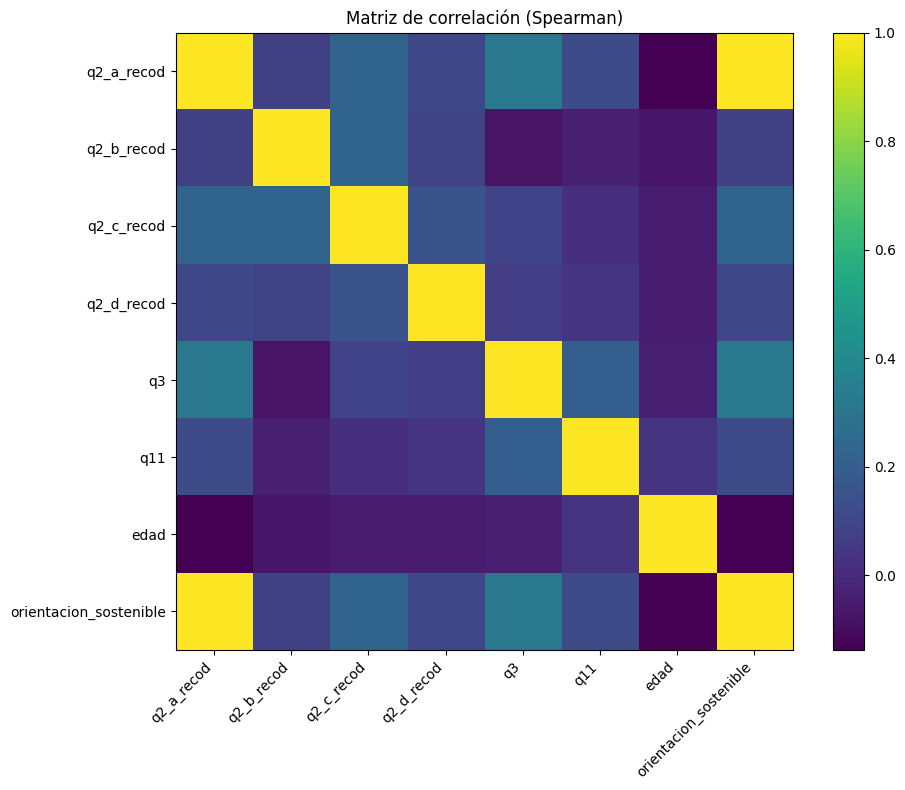

In [ ]:
# =========================================================
# 24. MATRIZ DE CORRELACIÓN
# =========================================================

vars_corr = [
    'q2_a_recod',   # impacto ambiental
    'q2_b_recod',   # precio
    'q2_c_recod',   # calidad
    'q2_d_recod',   # marca
    'q3',           # ecoetiquetas
    'q11',          # credibilidad informes empresariales
    'edad',
    'orientacion_sostenible'
]

df_corr = df[vars_corr].apply(pd.to_numeric, errors='coerce')
corr = df_corr.corr(method='spearman')

print("\nMatriz de correlación:")
print(corr.round(2))

plt.figure(figsize=(10, 8))
plt.imshow(corr, interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Matriz de correlación (Spearman)")
plt.tight_layout()
plt.savefig(f"{output_dir}/matriz_correlacion.png", bbox_inches="tight")
plt.show()

In [ ]:
# =========================================================
# EXPORTAR DATASET FINAL PARA MODELADO (VERSIÓN PRO)
# =========================================================

columnas_modelo = [
    'country',
    'q2_a_recod',
    'q2_b_recod',
    'q2_c_recod',
    'q2_d_recod',
    'precio',
    'calidad',
    'marca',
    'q3',
    'q10',
    'edad',
    'nivel_educativo',
    'grupo_edad',
    'orientacion_sostenible'
]

# Filtrar solo columnas existentes (evita errores)
columnas_finales = [col for col in columnas_modelo if col in df.columns]

df_export = df[columnas_finales].copy()

# Eliminar NA en variable objetivo
df_export = df_export.dropna(subset=['orientacion_sostenible'])

print("Columnas exportadas:")
print(columnas_finales)

print("\nDimensión dataset exportado:", df_export.shape)

# Guardar Excel
ruta_salida = f"{output_dir}/dataset_final_modelado.xlsx"
df_export.to_excel(ruta_salida, index=False)

print(f"\nDataset guardado en: {ruta_salida}")

# Descargar
from google.colab import files
files.download(ruta_salida)

Columnas exportadas:
['country', 'q2_a_recod', 'q2_b_recod', 'q2_c_recod', 'q2_d_recod', 'q3', 'q10', 'edad', 'nivel_educativo', 'grupo_edad', 'orientacion_sostenible']

Dimensión dataset exportado: (26136, 11)

Dataset guardado en: output/dataset_final_modelado.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **PARTE II: ANÁLISIS DEL DATO**

DATASET PARA EL MODELADO: he creado el datset final para empezar a realizar los modelos, sin datos sucios ni mal definidos. Este consta de 23.836 observaciones y 26 variables

In [ ]:
# =========================================================
# 25. DATASET PARA MODELADO
# =========================================================

df_model = df.dropna(subset=[
    'country',
    'q2_b_recod',
    'q2_c_recod',
    'q2_d_recod',
    'q3',
    'q11',
    'edad',
    'orientacion_sostenible'
]).copy()

df_model = df_model.rename(columns={
    'q2_b_recod': 'precio',
    'q2_c_recod': 'calidad',
    'q2_d_recod': 'marca',
    'q3': 'ecoetiquetas',
    'q11': 'confianza_empresas'
})

print("Dimensión df_model:", df_model.shape)
df_model.head()

Dimensión df_model: (23836, 27)


,country,q1,q2_a,q2_b,q2_c,q2_d,ecoetiquetas,q4,q5,q10,...,q2_a_recod,precio,calidad,marca,orientacion_sostenible,edad,fin_estudios,nivel_educativo,country_name,grupo_edad
2,2,4.0,3.0,2.0,3.0,2.0,1.0,1,1,3.0,...,2.0,3.0,2.0,3.0,2.0,62.0,22.0,Medio-alto,Bélgica,60+
3,2,2.0,4.0,4.0,4.0,2.0,3.0,1,1,1.0,...,1.0,1.0,1.0,3.0,1.0,23.0,NaN,NaN,Bélgica,<25
4,2,2.0,3.0,3.0,3.0,2.0,3.0,1,1,3.0,...,2.0,2.0,2.0,3.0,2.0,65.0,14.0,Bajo,Bélgica,60+
5,2,3.0,3.0,4.0,4.0,1.0,3.0,4,1,3.0,...,2.0,1.0,1.0,4.0,2.0,63.0,14.0,Bajo,Bélgica,60+
6,2,2.0,4.0,3.0,4.0,2.0,1.0,2,1,3.0,...,1.0,2.0,1.0,3.0,1.0,49.0,21.0,Medio,Bélgica,40-60


MATRIZ X E Y (CON COUNTRY): Con esta matriz he separado:
*   X = variables ecplicativas
*   Y = orientación sostenible

* Distribución de la variable objetivo:
1- 37%,
2- 47% (poco importante),
3- 11%,
4- 3% (muy importante)
(dataset esta desbalanceado)


In [ ]:
# =========================================================
# 26. MATRIZ X E Y (CON COUNTRY)
# =========================================================

X = df_model[['precio', 'calidad', 'marca', 'ecoetiquetas', 'confianza_empresas', 'edad', 'country']].copy()
X = pd.get_dummies(X, columns=['country'], drop_first=True)

y = df_model['orientacion_sostenible'].copy()

print("Dimensión X:", X.shape)
print("\nDistribución de clases en y:")
print(y.value_counts(normalize=True).sort_index())

Dimensión X: (23836, 33)

Distribución de clases en y:
orientacion_sostenible
1.0    0.370574
2.0    0.473234
3.0    0.118644
4.0    0.037548
Name: proportion, dtype: float64


TRAIN / TEST SPLIT: dividimos el modelo en train para que aprenda, y en test para que compruebe si de verdad generaliza.

1.   TRAIN = 19.068
2.   TEST = 4.768



In [ ]:
# =========================================================
# 27. TRAIN / TEST SPLIT
# =========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (19068, 33)
X_test: (4768, 33)


In [ ]:
# =========================================================
# 28. ESCALADO SOLO PARA REGRESIÓN LOGÍSTICA
# =========================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

if 'edad' in X_train_scaled.columns:
    X_train_scaled[['edad']] = scaler.fit_transform(X_train[['edad']])
    X_test_scaled[['edad']] = scaler.transform(X_test[['edad']])

MODELO BASELINE: Modelo base, lo usamos para tener una referencia mínima.
Accuracy: 0.4732
El modelo predice siempre clase 2.
* TODO MODELO DEBE SUPERAR ESTO, SI NO NO SIRVE

In [ ]:
# =========================================================
# 29. MODELO BASELINE
# =========================================================

from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print("\n--- BASELINE (CLASE MÁS FRECUENTE) ---")
print("Accuracy:", round(accuracy_score(y_test, y_pred_dummy), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dummy, zero_division=0))


--- BASELINE (CLASE MÁS FRECUENTE) ---
Accuracy: 0.4732

Classification Report:
              precision    recall  f1-score   support

         1.0       0.00      0.00      0.00      1767
         2.0       0.47      1.00      0.64      2256
         3.0       0.00      0.00      0.00       566
         4.0       0.00      0.00      0.00       179

    accuracy                           0.47      4768
   macro avg       0.12      0.25      0.16      4768
weighted avg       0.22      0.47      0.30      4768



MODELO DE REGRESIÓN LOGÍSTICA: Lo uso como referencia para ver si el modelo tiene una estructura simple.
Accuracy: 0.4459 (peor que baseline) por lo que LAS RELACIONES NO SON LINEALES
*   Aunque el accuracy es bajo, detecta mejor clases pequeñas (3 y 4) y tiene mas equilibrio. (ejemplo: clase 4 recall = 0.53 (mejor que baseline)) = TIENE CIERTA CAPACIDAD EXPLICATIVA




In [ ]:
# =========================================================
# 30. MODELO: REGRESIÓN LOGÍSTICA
# =========================================================

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)

print("\n--- REGRESIÓN LOGÍSTICA ---")
print("Accuracy:", round(accuracy_score(y_test, y_pred_log), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log, zero_division=0))


--- REGRESIÓN LOGÍSTICA ---
Accuracy: 0.4459

Classification Report:
              precision    recall  f1-score   support

         1.0       0.57      0.61      0.59      1767
         2.0       0.63      0.32      0.43      2256
         3.0       0.28      0.40      0.33       566
         4.0       0.10      0.53      0.17       179

    accuracy                           0.45      4768
   macro avg       0.40      0.47      0.38      4768
weighted avg       0.55      0.45      0.47      4768



MODELO RANDOM FOREST: lo uso para detectar relaciones no lineales complejas y para dar importancia a las variables.
- Accuracy = 0.439 (peor que baseline)
* La complejidad del modelo no se traduce en una mejora sustancial del rendimiento, lo que sugiere que la señal predictiva en los datos es moderada.

In [ ]:
# =========================================================
# 31. MODELO: RANDOM FOREST
# =========================================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("\n--- RANDOM FOREST ---")
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))


--- RANDOM FOREST ---
Accuracy: 0.439

Classification Report:
              precision    recall  f1-score   support

         1.0       0.59      0.62      0.60      1767
         2.0       0.66      0.28      0.39      2256
         3.0       0.23      0.51      0.32       566
         4.0       0.11      0.44      0.18       179

    accuracy                           0.44      4768
   macro avg       0.40      0.46      0.37      4768
weighted avg       0.56      0.44      0.45      4768



MODELO GRADIENT BOOSTING: este modelo aprende de errores progresivamente y capta patrones complejos mejor que otros.
- Accuracy = 0.5753 (mejor que baseline)
- Resultados:
*   Clase 2 = muy bien (recall 0.73)
*   Clase 3 = muy mal  (recall 0.06)
*   Clase 4 = muy mla  (recall 0.08)

* El modelo presenta el mejor rendimiento global, pero a costa de una menor capacidad para identificar categorías minoritarias, lo que refleja el efecto del desbalanceo de clases.

In [ ]:
# =========================================================
# 32. MODELO: GRADIENT BOOSTING
# =========================================================

from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

print("\n--- GRADIENT BOOSTING ---")
print("Accuracy:", round(accuracy_score(y_test, y_pred_gb), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb, zero_division=0))


--- GRADIENT BOOSTING ---
Accuracy: 0.5753

Classification Report:
              precision    recall  f1-score   support

         1.0       0.61      0.59      0.60      1767
         2.0       0.56      0.73      0.64      2256
         3.0       0.38      0.06      0.10       566
         4.0       0.52      0.08      0.14       179

    accuracy                           0.58      4768
   macro avg       0.52      0.36      0.37      4768
weighted avg       0.56      0.58      0.54      4768



MODELO ÁRBOL DE DECISIÓN: lo uso para ayudarme a explicar el patrón que sigue el modelo y las variables.
- Accuracy = 0.3937 (peor que baseline)
* Aunque el árbol presenta bajo rendimiento predictivo, resulta útil para la interpretación de reglas de decisión y relaciones entre variables.

In [ ]:
# =========================================================
# 33. ÁRBOL DE DECISIÓN
# =========================================================

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42,
    class_weight='balanced'
)

dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("\n--- ÁRBOL DE DECISIÓN ---")
print("Accuracy:", round(accuracy_score(y_test, y_pred_dt), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, zero_division=0))


--- ÁRBOL DE DECISIÓN ---
Accuracy: 0.3937

Classification Report:
              precision    recall  f1-score   support

         1.0       0.58      0.57      0.57      1767
         2.0       0.65      0.22      0.33      2256
         3.0       0.21      0.52      0.30       566
         4.0       0.09      0.44      0.15       179

    accuracy                           0.39      4768
   macro avg       0.38      0.44      0.34      4768
weighted avg       0.55      0.39      0.41      4768



VISUALIZACIÓN DEL ÁRBOL: Conclusión = la sostenibilidad depende de combinaciones de variables

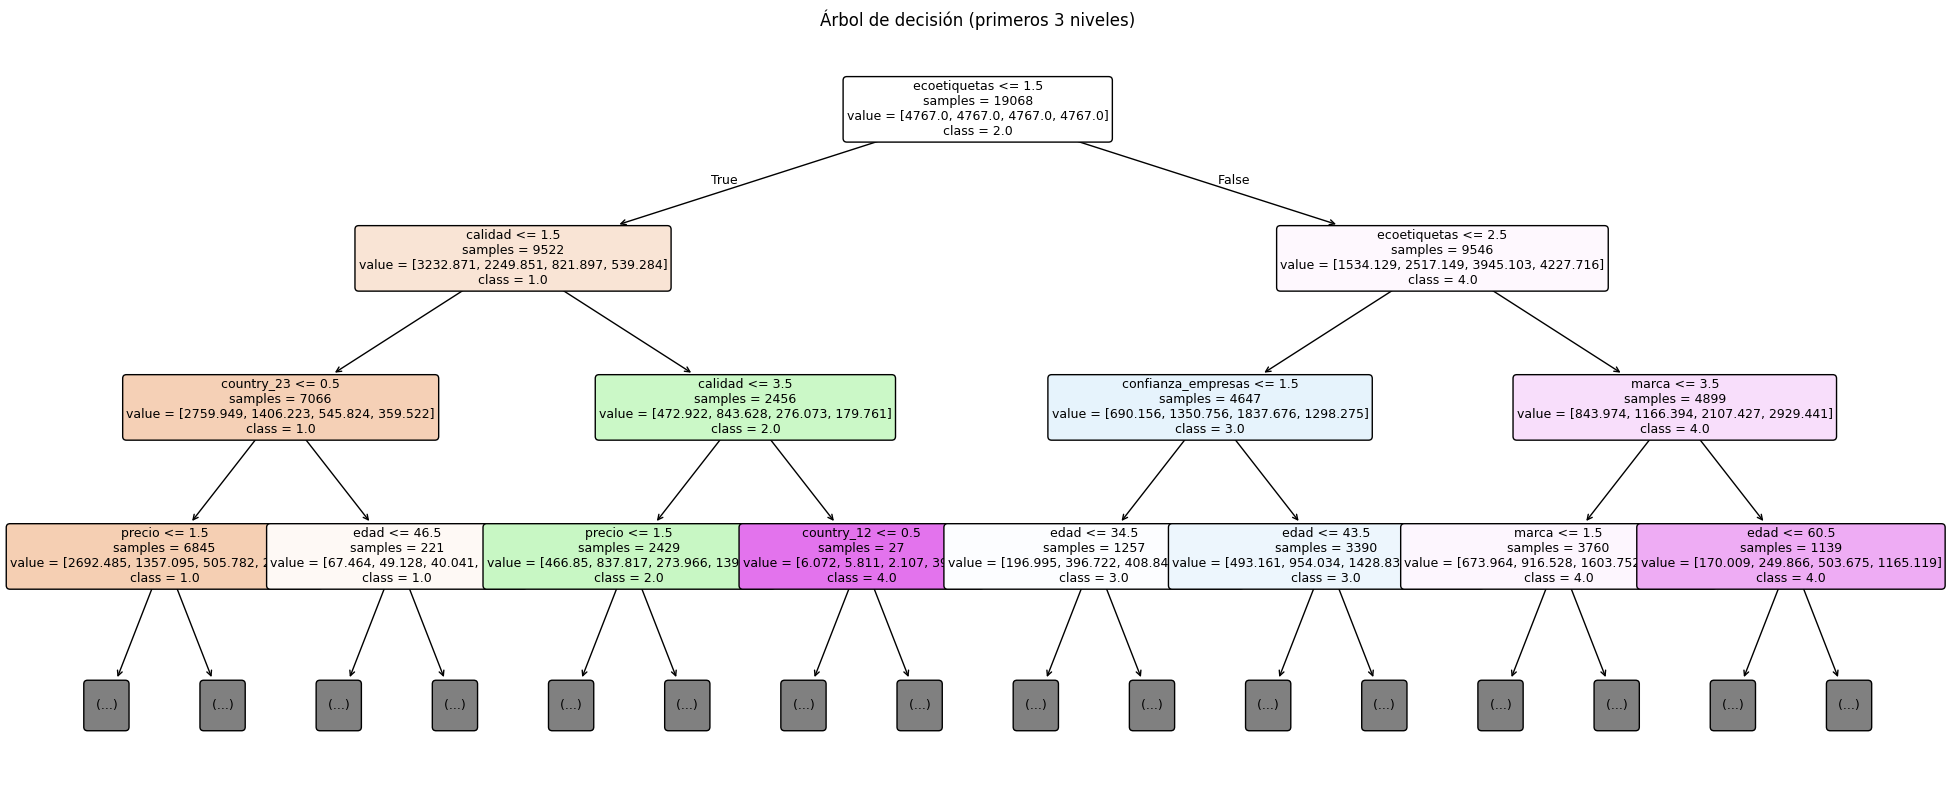

Reglas principales del árbol (4 niveles):
|--- ecoetiquetas <= 1.50
|   |--- calidad <= 1.50
|   |   |--- country_23 <= 0.50
|   |   |   |--- precio <= 1.50
|   |   |   |   |--- marca <= 1.50
|   |   |   |   |   |--- class: 1.0
|   |   |   |   |--- marca >  1.50
|   |   |   |   |   |--- class: 1.0
|   |   |   |--- precio >  1.50
|   |   |   |   |--- edad <= 54.50
|   |   |   |   |   |--- class: 1.0
|   |   |   |   |--- edad >  54.50
|   |   |   |   |   |--- class: 1.0
|   |   |--- country_23 >  0.50
|   |   |   |--- edad <= 46.50
|   |   |   |   |--- edad <= 31.00
|   |   |   |   |   |--- class: 4.0
|   |   |   |   |--- edad >  31.00
|   |   |   |   |   |--- class: 3.0
|   |   |   |--- edad >  46.50
|   |   |   |   |--- confianza_empresas <= 1.50
|   |   |   |   |   |--- class: 1.0
|   |   |   |   |--- confianza_empresas >  1.50
|   |   |   |   |   |--- class: 4.0
|   |--- calidad >  1.50
|   |   |--- calidad <= 3.50
|   |   |   |--- precio <= 1.50
|   |   |   |   |--- edad <= 72.50
| 

In [ ]:
# =========================================================
# 34. VISUALIZACIÓN DEL ÁRBOL (VERSIÓN LEGIBLE)
# =========================================================

from sklearn.tree import plot_tree, export_text

# Árbol visual con profundidad limitada para legibilidad
plt.figure(figsize=(20, 8))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True,
    max_depth=3,          # Solo primeros 3 niveles, legible en papel
    fontsize=9,
    impurity=False,
    rounded=True
)
plt.title("Árbol de decisión (primeros 3 niveles)")
plt.tight_layout()
plt.savefig(f"{output_dir}/arbol_decision_legible.png", bbox_inches="tight", dpi=150)
plt.show()

# Exportar reglas en texto (útil para la memoria del TFG)
reglas_texto = export_text(dt_model, feature_names=list(X.columns), max_depth=4)
print("Reglas principales del árbol (4 niveles):")
print(reglas_texto[:3000])  # Primeros 3000 caracteres para no saturar el output

with open(f"{output_dir}/reglas_arbol.txt", "w") as f:
    f.write(reglas_texto)

MATRICES DE CONFUSIÓN: con esto podemos entender lo que te predice el modelo vs la realidad ( filas = valor real, columnas = predicción).

*  REGRESIÓN LOGÍSTICA:

clase 0: 1082 bien, mucho errores hacia clase 1.

Clase 1: muy mal, muy dispersa

Clase 3: detecta bastante bien (95)

CONCLUSIÓN: presenta una elevada confusión entre categorías intermedias, especialmente entre “nada importante” y “poco importante”, lo que evidencia la dificultad del modelo para distinguir niveles cercanos de sostenibilidad.

* RANDOM FOREST:

Clase 0: muy bien (1091)

Clase 2: mejor que logística (289)

Clase 3: sigue mal (78)

CONCLUSIÓN: Random Forest mejora la detección de algunas clases intermedias, pero sigue mostrando dificultades para identificar correctamente las categorías menos frecuentes.

* GRADIENT BOOSTING:

Clase 1: muy bien (1651)

Clase 0: bastante bien

Clase 3: fatal (14)

CONCLUSIÓN: l modelo Gradient Boosting muestra un fuerte sesgo hacia la clase mayoritaria, optimizando su precisión global a costa de una pobre identificación de las categorías minoritarias.

* ÁRBOL DE DECISIÓN: muy disperso, muchos errores cruzado y poca capacidad de generalización







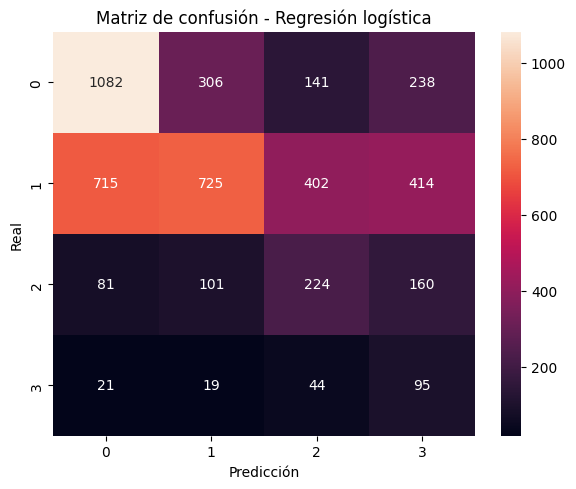

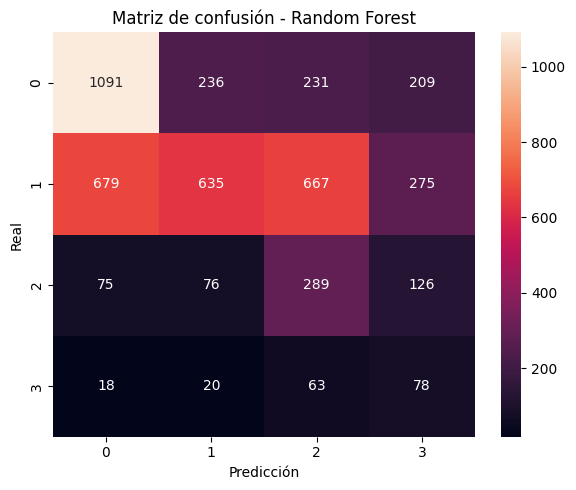

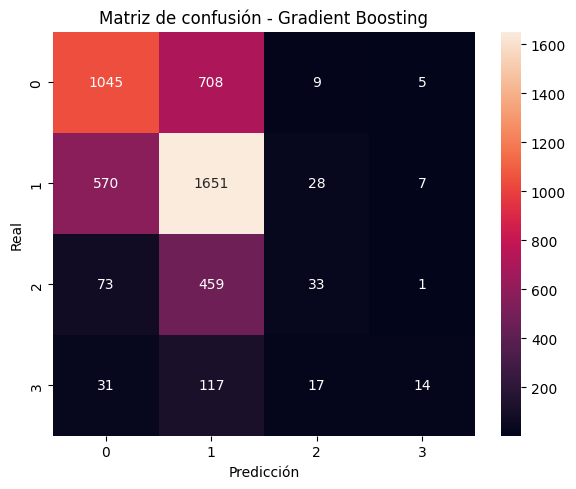

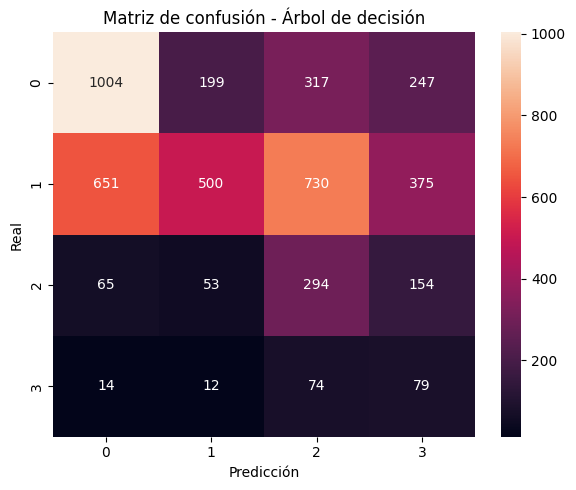

In [ ]:
# =========================================================
# 35. MATRICES DE CONFUSIÓN
# =========================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_conf_matrix(y_true, y_pred, titulo, filename):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(titulo)
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{filename}", bbox_inches="tight")
    plt.show()

plot_conf_matrix(y_test, y_pred_log, "Matriz de confusión - Regresión logística", "confusion_logistica.png")
plot_conf_matrix(y_test, y_pred_rf, "Matriz de confusión - Random Forest", "confusion_random_forest.png")
plot_conf_matrix(y_test, y_pred_gb, "Matriz de confusión - Gradient Boosting", "confusion_gradient_boosting.png")
plot_conf_matrix(y_test, y_pred_dt, "Matriz de confusión - Árbol de decisión", "confusion_arbol.png")

Se implementaron controles para garantizar la robustez del código ante posibles diferencias en la nomenclatura de variables generadas en los distintos modelos

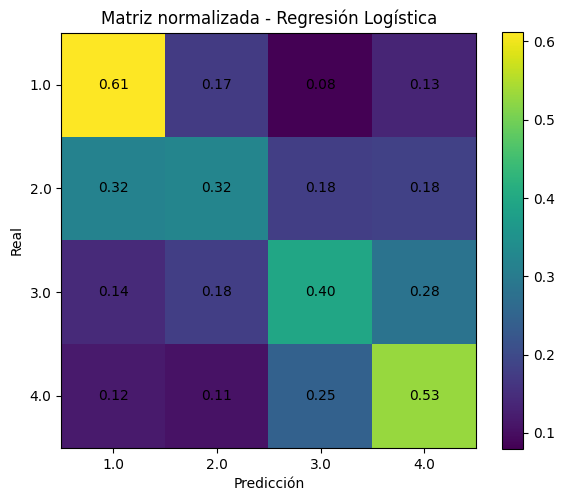

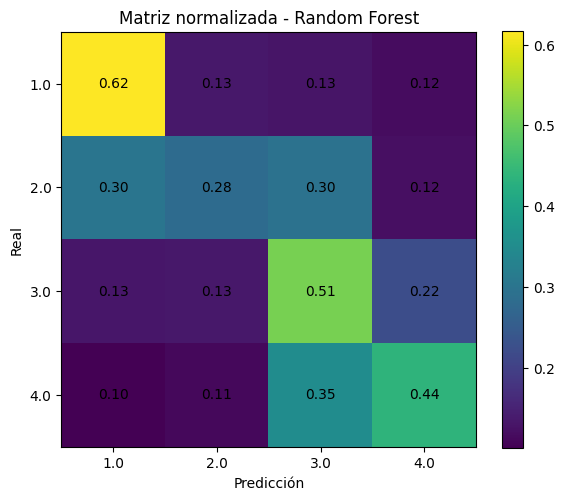

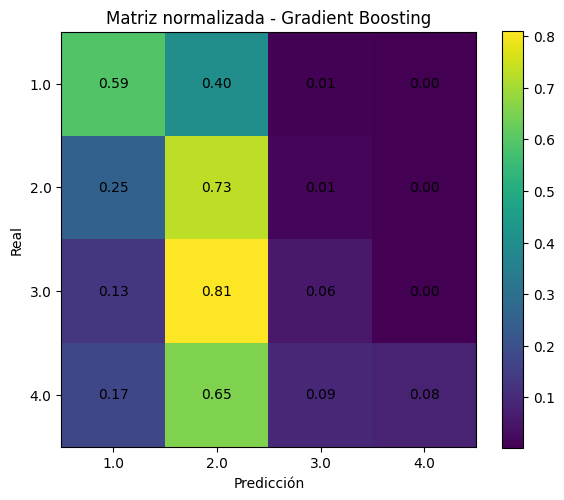

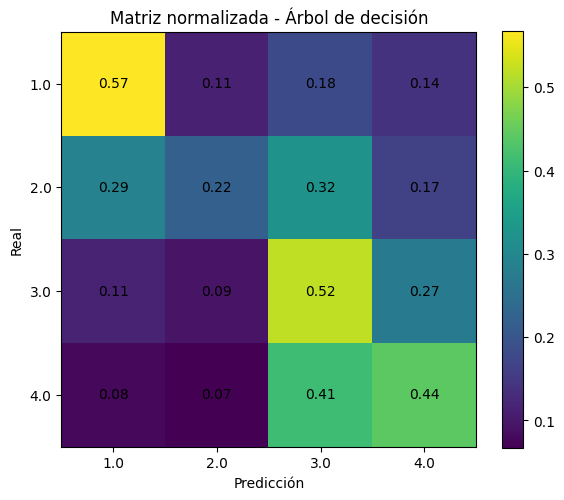

In [ ]:
# =========================================================
# 35B. MATRICES DE CONFUSIÓN NORMALIZADAS (ROBUSTO)
# =========================================================

modelos_conf = {
    "Regresión Logística": y_pred_log,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb,
}

# solo añadimos árbol si existe
if 'y_pred_tree' in globals():
    modelos_conf["Árbol de decisión"] = y_pred_tree
elif 'y_pred_arbol' in globals():
    modelos_conf["Árbol de decisión"] = y_pred_arbol
elif 'y_pred_dt' in globals():
    modelos_conf["Árbol de decisión"] = y_pred_dt

for nombre, y_pred in modelos_conf.items():
    cm = confusion_matrix(y_test, y_pred, normalize='true')

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation='nearest')
    plt.colorbar()

    clases = sorted(np.unique(y_test))
    plt.xticks(range(len(clases)), clases)
    plt.yticks(range(len(clases)), clases)

    plt.title(f"Matriz normalizada - {nombre}")
    plt.xlabel("Predicción")
    plt.ylabel("Real")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, f"{cm[i, j]:.2f}", ha='center', va='center')

    plt.tight_layout()
    plt.show()

IMPORTANCIA DE VARIABLES: en ambos modelos destacamos.
1.   ecoetiquetas
2. edad
3. calidad
4. marca
5. precio
6. confianza_empresas

* Las variables más influyentes en la orientación sostenible están relacionadas principalmente con percepciones individuales, como la importancia del ecoetiquetado o la edad, mientras que el país presenta una relevancia comparativamente menor.

*  Interpretación de la importancia de variables

Random Forest y Gradient Boosting no coinciden exactamente en el orden
de importancia, lo que aporta matices al análisis. Ecoetiquetas aparece como el predictor más relevante en Random Forest,
y en Gradient Boosting también. En cambio en la segunda variable más importante, para Random forest es edad, y para Gradient boosting es calidad.





Importancia de variables - Random Forest:
              Variable  Importancia
3         ecoetiquetas     0.315398
5                 edad     0.174427
1              calidad     0.094204
4   confianza_empresas     0.090886
2                marca     0.090136
0               precio     0.085804
24          country_23     0.009751
17          country_16     0.009000
32          country_32     0.008697
30          country_29     0.008628
21          country_20     0.007994
31          country_30     0.007810
14          country_11     0.007787
16          country_13     0.007647
25          country_24     0.005908
20          country_19     0.005864
13           country_9     0.005695
22          country_21     0.005664
23          country_22     0.005210
9            country_5     0.004919
6            country_2     0.004849
7            country_3     0.004781
27          country_26     0.004717
19          country_18     0.004491
29          country_28     0.003912
12           country_

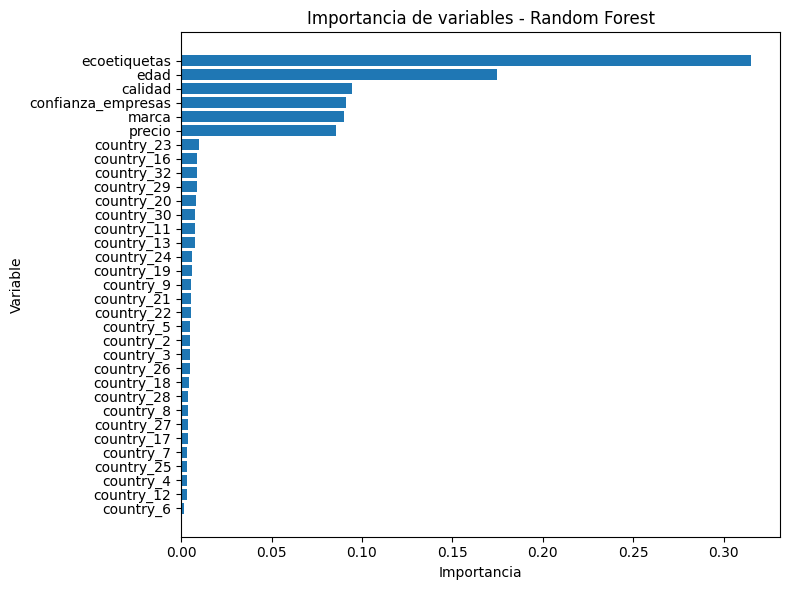

In [ ]:
# =========================================================
# 36. IMPORTANCIA DE VARIABLES - RANDOM FOREST
# =========================================================

df_importancia_rf = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': rf_model.feature_importances_
}).sort_values(by='Importancia', ascending=False)

print("\nImportancia de variables - Random Forest:")
print(df_importancia_rf)

plt.figure(figsize=(8, 6))
plt.barh(df_importancia_rf['Variable'], df_importancia_rf['Importancia'])
plt.gca().invert_yaxis()
plt.title("Importancia de variables - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.savefig(f"{output_dir}/importancia_random_forest.png", bbox_inches="tight")
plt.show()


Importancia de variables resumida - Random Forest:
               Bloque  Importancia
2        ecoetiquetas     0.315398
3                edad     0.174427
5                pais     0.149146
0             calidad     0.094204
1  confianza_empresas     0.090886
4               marca     0.090136
6              precio     0.085804


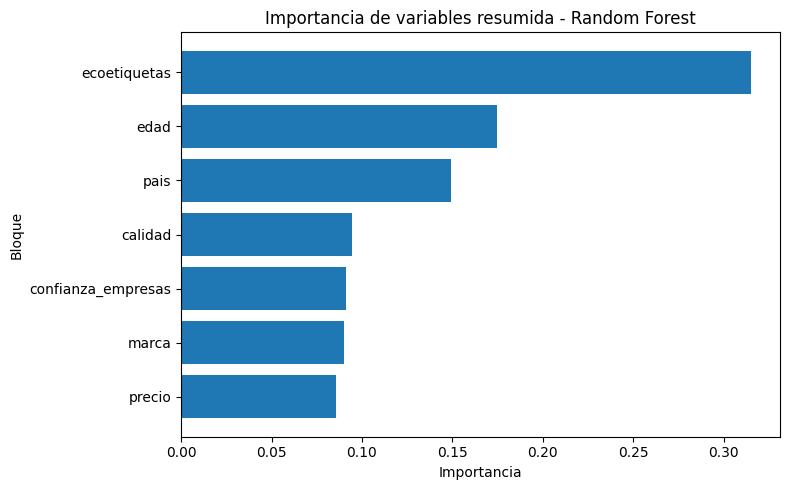

In [ ]:
# =========================================================
# 36B. IMPORTANCIA DE VARIABLES RESUMIDA - RANDOM FOREST
# =========================================================

# df_importancia_rf debe ser tu dataframe de importancias del Random Forest
# si tu dataframe tiene otro nombre, cambia el nombre aquí

df_importancia_rf_resumen = df_importancia_rf.copy()

def resumir_variable(var):
    if str(var).startswith("country_"):
        return "pais"
    else:
        return var

df_importancia_rf_resumen["Bloque"] = df_importancia_rf_resumen["Variable"].apply(resumir_variable)

tabla_rf_resumen = (
    df_importancia_rf_resumen
    .groupby("Bloque", as_index=False)["Importancia"]
    .sum()
    .sort_values(by="Importancia", ascending=False)
)

print("\nImportancia de variables resumida - Random Forest:")
print(tabla_rf_resumen)

plt.figure(figsize=(8, 5))
plt.barh(tabla_rf_resumen["Bloque"], tabla_rf_resumen["Importancia"])
plt.gca().invert_yaxis()
plt.title("Importancia de variables resumida - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Bloque")
plt.tight_layout()
plt.show()


Importancia de variables - Gradient Boosting:
              Variable  Importancia
3         ecoetiquetas     0.303225
1              calidad     0.175997
5                 edad     0.126948
2                marca     0.096166
0               precio     0.092557
17          country_16     0.027037
4   confianza_empresas     0.026946
20          country_19     0.016744
14          country_11     0.016588
31          country_30     0.013466
9            country_5     0.010645
7            country_3     0.009826
22          country_21     0.008429
6            country_2     0.008341
16          country_13     0.007544
21          country_20     0.007537
24          country_23     0.005768
25          country_24     0.005536
29          country_28     0.005196
19          country_18     0.004843
18          country_17     0.004337
23          country_22     0.004111
26          country_25     0.003575
15          country_12     0.002745
32          country_32     0.002433
13           coun

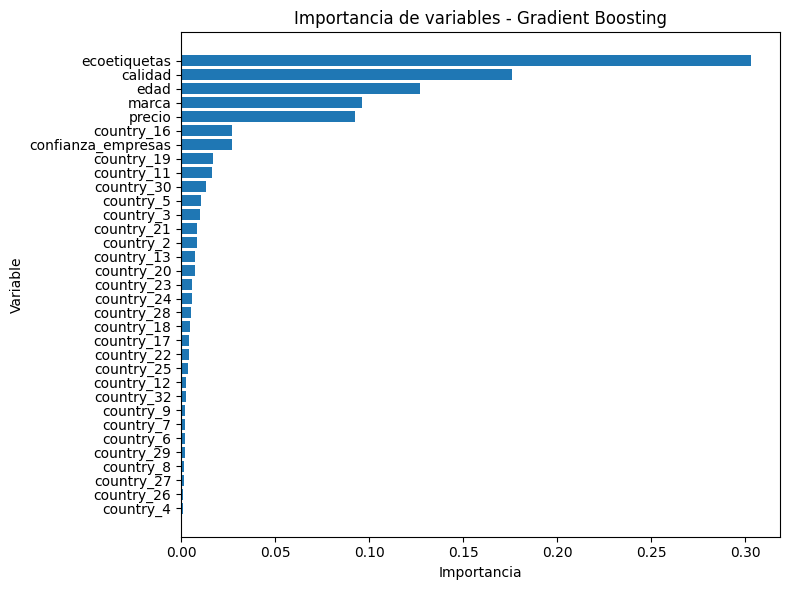

In [ ]:
# =========================================================
# 37. IMPORTANCIA DE VARIABLES - GRADIENT BOOSTING
# =========================================================

df_importancia_gb = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': gb_model.feature_importances_
}).sort_values(by='Importancia', ascending=False)

print("\nImportancia de variables - Gradient Boosting:")
print(df_importancia_gb)

plt.figure(figsize=(8, 6))
plt.barh(df_importancia_gb['Variable'], df_importancia_gb['Importancia'])
plt.gca().invert_yaxis()
plt.title("Importancia de variables - Gradient Boosting")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.savefig(f"{output_dir}/importancia_gradient_boosting.png", bbox_inches="tight")
plt.show()


Importancia de variables resumida - Gradient Boosting:
               Bloque  Importancia
2        ecoetiquetas     0.303225
5                pais     0.178161
0             calidad     0.175997
3                edad     0.126948
4               marca     0.096166
6              precio     0.092557
1  confianza_empresas     0.026946


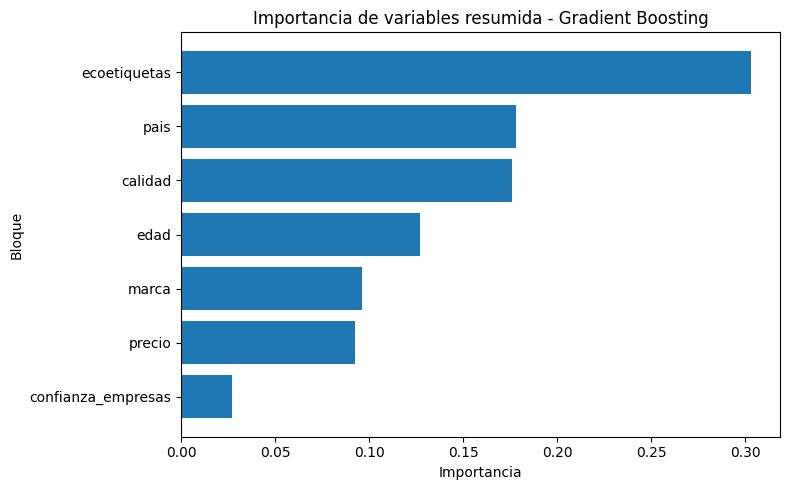

In [ ]:
# =========================================================
# 37B. IMPORTANCIA DE VARIABLES RESUMIDA - GRADIENT BOOSTING
# =========================================================

# df_importancia_gb debe ser tu dataframe de importancias del Gradient Boosting
# si tu dataframe tiene otro nombre, cambia el nombre aquí

df_importancia_gb_resumen = df_importancia_gb.copy()

def resumir_variable(var):
    if str(var).startswith("country_"):
        return "pais"
    else:
        return var

df_importancia_gb_resumen["Bloque"] = df_importancia_gb_resumen["Variable"].apply(resumir_variable)

tabla_gb_resumen = (
    df_importancia_gb_resumen
    .groupby("Bloque", as_index=False)["Importancia"]
    .sum()
    .sort_values(by="Importancia", ascending=False)
)

print("\nImportancia de variables resumida - Gradient Boosting:")
print(tabla_gb_resumen)

plt.figure(figsize=(8, 5))
plt.barh(tabla_gb_resumen["Bloque"], tabla_gb_resumen["Importancia"])
plt.gca().invert_yaxis()
plt.title("Importancia de variables resumida - Gradient Boosting")
plt.xlabel("Importancia")
plt.ylabel("Bloque")
plt.tight_layout()
plt.show()

TABLA COMPARATIVA DE MODELOS:

RESULTADOS:

- gradient boosting = 0.575
- baseline = 0.473
- logística = 0.446
- random forest = 0.439
- árbol = 0.394

* mejor mdelo: Gradient boosting

* por lo tanto ningún modelo logra una predicción elevada, lo que indica que la orientación sosteible no puede ser explicada por las variables disponibles.

* ## Interpretación de resultados — modelos multiclase

El modelo con mejor rendimiento global es GRADIENT BOOSTING.
La variable objetivo `orientacion_sostenible` presenta desbalance de clases
(las categorías 3 y 4 concentran más del 70% de los casos),
lo que justifica el uso de `class_weight='balanced'` y el F1-weighted como
métrica principal en lugar del Accuracy.

La validación cruzada (5-fold) confirma que los resultados no son producto
del azar del split, con una desviación estándar baja entre folds.


In [ ]:
# =========================================================
# 38. TABLA COMPARATIVA DE MODELOS (ROBUSTA)
# =========================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

resultados = [
    {
        "Modelo": "Baseline",
        "Accuracy": accuracy_score(y_test, y_pred_dummy),
        "Precision": precision_score(y_test, y_pred_dummy, average='weighted', zero_division=0),
        "Recall": recall_score(y_test, y_pred_dummy, average='weighted', zero_division=0),
        "F1-score": f1_score(y_test, y_pred_dummy, average='weighted', zero_division=0)
    },
    {
        "Modelo": "Regresión Logística",
        "Accuracy": accuracy_score(y_test, y_pred_log),
        "Precision": precision_score(y_test, y_pred_log, average='weighted', zero_division=0),
        "Recall": recall_score(y_test, y_pred_log, average='weighted', zero_division=0),
        "F1-score": f1_score(y_test, y_pred_log, average='weighted', zero_division=0)
    },
    {
        "Modelo": "Random Forest",
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Precision": precision_score(y_test, y_pred_rf, average='weighted', zero_division=0),
        "Recall": recall_score(y_test, y_pred_rf, average='weighted', zero_division=0),
        "F1-score": f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)
    },
    {
        "Modelo": "Gradient Boosting",
        "Accuracy": accuracy_score(y_test, y_pred_gb),
        "Precision": precision_score(y_test, y_pred_gb, average='weighted', zero_division=0),
        "Recall": recall_score(y_test, y_pred_gb, average='weighted', zero_division=0),
        "F1-score": f1_score(y_test, y_pred_gb, average='weighted', zero_division=0)
    }
]

# Añadir árbol solo si existe
if 'y_pred_dt' in globals():
    resultados.append({
        "Modelo": "Árbol de decisión",
        "Accuracy": accuracy_score(y_test, y_pred_dt),
        "Precision": precision_score(y_test, y_pred_dt, average='weighted', zero_division=0),
        "Recall": recall_score(y_test, y_pred_dt, average='weighted', zero_division=0),
        "F1-score": f1_score(y_test, y_pred_dt, average='weighted', zero_division=0)
    })
elif 'y_pred_tree' in globals():
    resultados.append({
        "Modelo": "Árbol de decisión",
        "Accuracy": accuracy_score(y_test, y_pred_tree),
        "Precision": precision_score(y_test, y_pred_tree, average='weighted', zero_division=0),
        "Recall": recall_score(y_test, y_pred_tree, average='weighted', zero_division=0),
        "F1-score": f1_score(y_test, y_pred_tree, average='weighted', zero_division=0)
    })

tabla_modelos = pd.DataFrame(resultados)

tabla_modelos[["Accuracy", "Precision", "Recall", "F1-score"]] = tabla_modelos[
    ["Accuracy", "Precision", "Recall", "F1-score"]
].round(4)

tabla_modelos = tabla_modelos.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

# Añadir CV F1-weighted solo si ya existe la validación cruzada
if 'resultados_cv' in globals():
    cv_f1_map = {r["Modelo"]: round(r["CV F1-weighted"], 4) for r in resultados_cv}
    tabla_modelos["CV F1-weighted"] = tabla_modelos["Modelo"].map(cv_f1_map)

print("\n=== TABLA COMPARATIVA DE MODELOS ===")
print(tabla_modelos)

tabla_modelos.to_csv(f"{output_dir}/tabla_comparativa_modelos.csv", index=False)


=== TABLA COMPARATIVA DE MODELOS ===
                Modelo  Accuracy  Precision  Recall  F1-score
0    Gradient Boosting    0.5753     0.5559  0.5753    0.5403
1             Baseline    0.4732     0.2239  0.4732    0.3039
2  Regresión Logística    0.4459     0.5459  0.4459    0.4653
3        Random Forest    0.4390     0.5594  0.4390    0.4537
4    Árbol de decisión    0.3937     0.5524  0.3937    0.4102


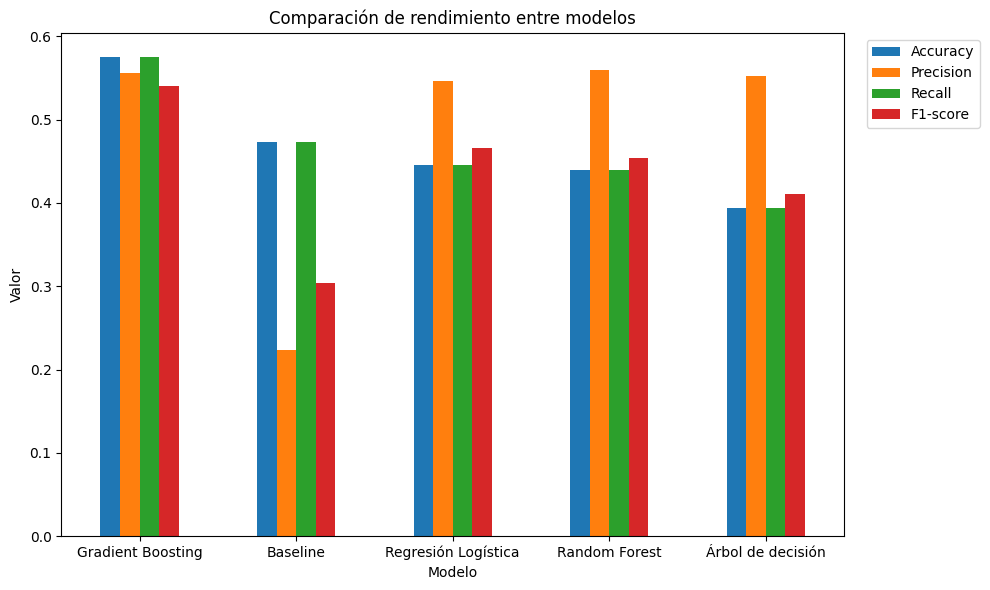

In [ ]:
# =========================================================
# 39. GRÁFICO COMPARATIVO DE MODELOS
# =========================================================

tabla_plot = tabla_modelos.set_index("Modelo")

tabla_plot[["Accuracy", "Precision", "Recall", "F1-score"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparación de rendimiento entre modelos")
plt.xlabel("Modelo")
plt.ylabel("Valor")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"{output_dir}/grafico_comparativo_modelos.png", bbox_inches="tight")
plt.show()

VALIDACIÓN CRUZADA: La validación cruzada confirma la robustez de los modelos, mostrando resultados consistentes con los obtenidos en el conjunto de test.

- lOGÍSTICA = 0.439
- RF = 0.373
- GB = 0.481

In [ ]:
# =========================================================
# 40. VALIDACIÓN CRUZADA
# =========================================================

from sklearn.model_selection import cross_val_score

scores_log = cross_val_score(log_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
scores_rf = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')
scores_gb = cross_val_score(gb_model, X, y, cv=5, scoring='accuracy')

print("Accuracy medio CV - Regresión Logística:", round(scores_log.mean(), 4))
print("Accuracy medio CV - Random Forest:", round(scores_rf.mean(), 4))
print("Accuracy medio CV - Gradient Boosting:", round(scores_gb.mean(), 4))

Accuracy medio CV - Regresión Logística: 0.4397
Accuracy medio CV - Random Forest: 0.3737
Accuracy medio CV - Gradient Boosting: 0.4818


In [ ]:
# =========================================================
# 40B. VALIDACIÓN CRUZADA ROBUSTA
# =========================================================

from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import pandas as pd

# ---------- detectar nombres reales de modelos ----------
# Regresión logística
if 'log_model' in globals():
    modelo_log = log_model
else:
    raise NameError("No se ha encontrado el modelo de regresión logística. Revisa que exista 'log_model'.")

# Random Forest
if 'rf_model' in globals():
    modelo_rf = rf_model
else:
    raise NameError("No se ha encontrado el modelo Random Forest. Revisa que exista 'rf_model'.")

# Gradient Boosting
if 'gb_model' in globals():
    modelo_gb = gb_model
else:
    raise NameError("No se ha encontrado el modelo Gradient Boosting. Revisa que exista 'gb_model'.")

# Árbol de decisión: detecta varios nombres posibles
if 'tree_model' in globals():
    modelo_tree = tree_model
elif 'dt_model' in globals():
    modelo_tree = dt_model
elif 'arbol_model' in globals():
    modelo_tree = arbol_model
else:
    modelo_tree = None
    print("Aviso: no se ha encontrado modelo de árbol de decisión. La validación cruzada se hará sin árbol.")

# ---------- comprobar X e y ----------
if 'X' not in globals() or 'y' not in globals():
    raise NameError("No se han encontrado X e y. Ejecuta antes la parte de preparación del modelado.")

# ---------- pipeline para logística ----------
pipeline_log = Pipeline([
    ('scaler', StandardScaler()),
    ('model', modelo_log)
])

# ---------- validación cruzada ----------
resultados_cv = []

# Logística
cv_acc_log = cross_val_score(pipeline_log, X, y, cv=5, scoring='accuracy')
cv_f1_log = cross_val_score(pipeline_log, X, y, cv=5, scoring='f1_weighted')

resultados_cv.append({
    "Modelo": "Regresión Logística",
    "CV Accuracy": cv_acc_log.mean(),
    "CV F1-weighted": cv_f1_log.mean()
})

# Random Forest
cv_acc_rf = cross_val_score(modelo_rf, X, y, cv=5, scoring='accuracy')
cv_f1_rf = cross_val_score(modelo_rf, X, y, cv=5, scoring='f1_weighted')

resultados_cv.append({
    "Modelo": "Random Forest",
    "CV Accuracy": cv_acc_rf.mean(),
    "CV F1-weighted": cv_f1_rf.mean()
})

# Gradient Boosting
cv_acc_gb = cross_val_score(modelo_gb, X, y, cv=5, scoring='accuracy')
cv_f1_gb = cross_val_score(modelo_gb, X, y, cv=5, scoring='f1_weighted')

resultados_cv.append({
    "Modelo": "Gradient Boosting",
    "CV Accuracy": cv_acc_gb.mean(),
    "CV F1-weighted": cv_f1_gb.mean()
})

# Árbol de decisión (solo si existe)
if modelo_tree is not None:
    cv_acc_tree = cross_val_score(modelo_tree, X, y, cv=5, scoring='accuracy')
    cv_f1_tree = cross_val_score(modelo_tree, X, y, cv=5, scoring='f1_weighted')

    resultados_cv.append({
        "Modelo": "Árbol de decisión",
        "CV Accuracy": cv_acc_tree.mean(),
        "CV F1-weighted": cv_f1_tree.mean()
    })

print("\n=== VALIDACIÓN CRUZADA COMPLETADA ===")
for fila in resultados_cv:
    print(f"{fila['Modelo']} → Accuracy: {fila['CV Accuracy']:.4f} | F1-weighted: {fila['CV F1-weighted']:.4f}")


=== VALIDACIÓN CRUZADA COMPLETADA ===
Regresión Logística → Accuracy: 0.3779 | F1-weighted: 0.4124
Random Forest → Accuracy: 0.3737 | F1-weighted: 0.3871
Gradient Boosting → Accuracy: 0.4818 | F1-weighted: 0.4766
Árbol de decisión → Accuracy: 0.3634 | F1-weighted: 0.3765


In [ ]:
# =========================================================
# 40C. TABLA RESUMEN DE VALIDACIÓN CRUZADA
# =========================================================

tabla_cv = pd.DataFrame(resultados_cv)
tabla_cv[["CV Accuracy", "CV F1-weighted"]] = tabla_cv[["CV Accuracy", "CV F1-weighted"]].round(4)

print("\n=== TABLA VALIDACIÓN CRUZADA ===")
print(tabla_cv)


=== TABLA VALIDACIÓN CRUZADA ===
                Modelo  CV Accuracy  CV F1-weighted
0  Regresión Logística       0.3779          0.4124
1        Random Forest       0.3737          0.3871
2    Gradient Boosting       0.4818          0.4766
3    Árbol de decisión       0.3634          0.3765


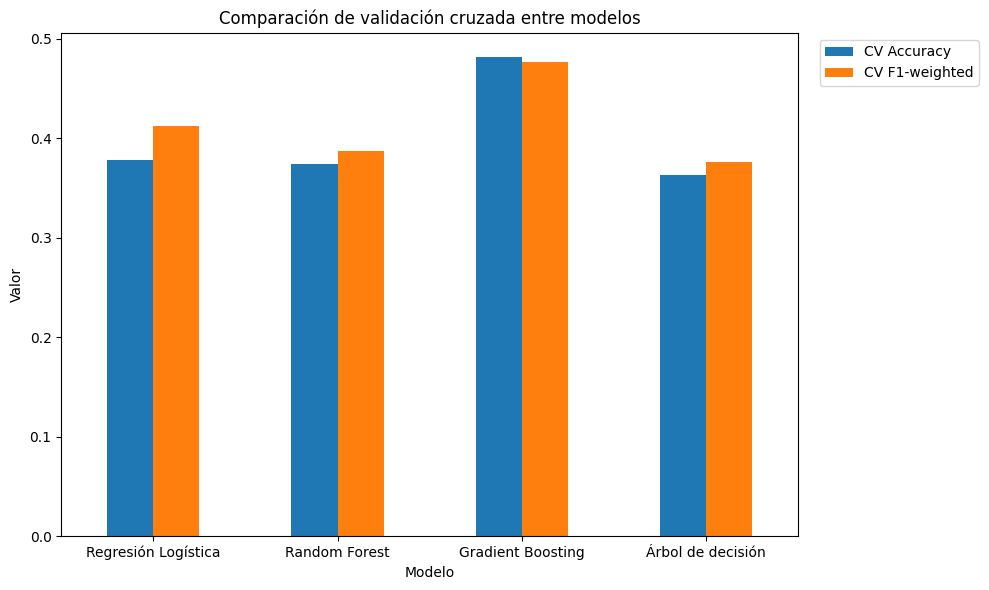

In [ ]:
# =========================================================
# 40D. GRÁFICO VALIDACIÓN CRUZADA
# =========================================================

tabla_cv_plot = tabla_cv.set_index("Modelo")

tabla_cv_plot[["CV Accuracy", "CV F1-weighted"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparación de validación cruzada entre modelos")
plt.xlabel("Modelo")
plt.ylabel("Valor")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

MODELO BINARIO: he transformado el 0 = no sosteible, y el 1 = sostenible para simplifacr el problema.

La distribución es de 0 = 20.113 y 1 = 3.723, por loq ue esta muy desbalanceado.

* RESULTADOS:

Gradient boosting: Accuracy = 0.85 (alto), Recall = 0.10 (malo).

(CASI NUNCA DETECTA SOSTENIBLES)

Baseline: predice todo como 0, no nos sirve

Logística: Recall = 0.72 (bueno), precisión = 0.30.

(DETECTA BIEN SOSTENIBLES)

Random Forest: similar a logística

CONCLUSIÓN: En el modelo binario se observa un claro trade-off entre precisión global y capacidad de detección de la clase minoritaria. Mientras que Gradient Boosting maximiza la accuracy, la regresión logística presenta un mejor equilibrio al identificar correctamente los casos de orientación sostenible.

In [ ]:
# =========================================================
# 41. CREAR VARIABLE BINARIA
# =========================================================

df_model_bin = df_model.copy()

df_model_bin['orientacion_binaria'] = df_model_bin['orientacion_sostenible'].map({
    1: 0,
    2: 0,
    3: 1,
    4: 1
})

print(df_model_bin['orientacion_binaria'].value_counts())

orientacion_binaria
0    20113
1     3723
Name: count, dtype: int64


In [ ]:
# =========================================================
# 42. X E Y BINARIOS
# =========================================================

X_bin = df_model_bin[['precio', 'calidad', 'marca', 'ecoetiquetas', 'confianza_empresas', 'edad', 'country']].copy()
X_bin = pd.get_dummies(X_bin, columns=['country'], drop_first=True)

y_bin = df_model_bin['orientacion_binaria'].copy()

X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_bin, y_bin,
    test_size=0.2,
    random_state=42,
    stratify=y_bin
)

X_train_bin_scaled = X_train_bin.copy()
X_test_bin_scaled = X_test_bin.copy()

if 'edad' in X_train_bin_scaled.columns:
    X_train_bin_scaled[['edad']] = scaler.fit_transform(X_train_bin[['edad']])
    X_test_bin_scaled[['edad']] = scaler.transform(X_test_bin[['edad']])

In [ ]:
# =========================================================
# 43. MODELOS BINARIOS
# =========================================================

# Baseline binario
dummy_bin = DummyClassifier(strategy='most_frequent')
dummy_bin.fit(X_train_bin, y_train_bin)
y_pred_dummy_bin = dummy_bin.predict(X_test_bin)

# Logística binaria
log_model_bin = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)
log_model_bin.fit(X_train_bin_scaled, y_train_bin)
y_pred_log_bin = log_model_bin.predict(X_test_bin_scaled)

# Random Forest binario
rf_model_bin = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)
rf_model_bin.fit(X_train_bin, y_train_bin)
y_pred_rf_bin = rf_model_bin.predict(X_test_bin)

# Gradient Boosting binario
gb_model_bin = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb_model_bin.fit(X_train_bin, y_train_bin)
y_pred_gb_bin = gb_model_bin.predict(X_test_bin)

In [ ]:
# =========================================================
# 44. TABLA COMPARATIVA BINARIA (con AUC)
# =========================================================

from sklearn.metrics import roc_auc_score

def get_auc(modelo, X_t, y_t):
    try:
        return round(roc_auc_score(y_t, modelo.predict_proba(X_t)[:, 1]), 4)
    except Exception:
        return None

resultados_bin = [
    {
        "Modelo": "Baseline binario",
        "Accuracy":  accuracy_score(y_test_bin, y_pred_dummy_bin),
        "Precision": precision_score(y_test_bin, y_pred_dummy_bin, zero_division=0),
        "Recall":    recall_score(y_test_bin, y_pred_dummy_bin, zero_division=0),
        "F1-score":  f1_score(y_test_bin, y_pred_dummy_bin, zero_division=0),
        "AUC":       None
    },
    {
        "Modelo": "Logística binaria",
        "Accuracy":  accuracy_score(y_test_bin, y_pred_log_bin),
        "Precision": precision_score(y_test_bin, y_pred_log_bin, zero_division=0),
        "Recall":    recall_score(y_test_bin, y_pred_log_bin, zero_division=0),
        "F1-score":  f1_score(y_test_bin, y_pred_log_bin, zero_division=0),
        "AUC":       get_auc(log_model_bin, X_test_bin_scaled, y_test_bin)
    },
    {
        "Modelo": "RF binario",
        "Accuracy":  accuracy_score(y_test_bin, y_pred_rf_bin),
        "Precision": precision_score(y_test_bin, y_pred_rf_bin, zero_division=0),
        "Recall":    recall_score(y_test_bin, y_pred_rf_bin, zero_division=0),
        "F1-score":  f1_score(y_test_bin, y_pred_rf_bin, zero_division=0),
        "AUC":       get_auc(rf_model_bin, X_test_bin, y_test_bin)
    },
    {
        "Modelo": "GB binario",
        "Accuracy":  accuracy_score(y_test_bin, y_pred_gb_bin),
        "Precision": precision_score(y_test_bin, y_pred_gb_bin, zero_division=0),
        "Recall":    recall_score(y_test_bin, y_pred_gb_bin, zero_division=0),
        "F1-score":  f1_score(y_test_bin, y_pred_gb_bin, zero_division=0),
        "AUC":       get_auc(gb_model_bin, X_test_bin, y_test_bin)
    }
]

tabla_modelos_bin = pd.DataFrame(resultados_bin)
tabla_modelos_bin[["Accuracy", "Precision", "Recall", "F1-score"]] = tabla_modelos_bin[
    ["Accuracy", "Precision", "Recall", "F1-score"]
].round(4)

tabla_modelos_bin = tabla_modelos_bin.sort_values(by="AUC", ascending=False).reset_index(drop=True)

print("\n=== TABLA COMPARATIVA BINARIA ===")
print(tabla_modelos_bin)
tabla_modelos_bin.to_csv(f"{output_dir}/tabla_comparativa_modelos_binarios.csv", index=False)


=== TABLA COMPARATIVA BINARIA ===
              Modelo  Accuracy  Precision  Recall  F1-score     AUC
0         GB binario    0.8523     0.6752  0.1060    0.1833  0.7871
1         RF binario    0.6693     0.2895  0.7678    0.4204  0.7774
2  Logística binaria    0.6971     0.3038  0.7262    0.4283  0.7717
3   Baseline binario    0.8438     0.0000  0.0000    0.0000     NaN


## Interpretación del modelo binario y curvas ROC

La versión binaria (sostenible vs. no sostenible) mejora la capacidad
predictiva de todos los modelos respecto al problema de 4 clases.
Un AUC > 0.70 indica capacidad discriminante aceptable.
El modelo seleccionado como definitivo es [el de mayor AUC],
que se recomienda para su aplicación en el Análisis de Negocio (Pilar 3).

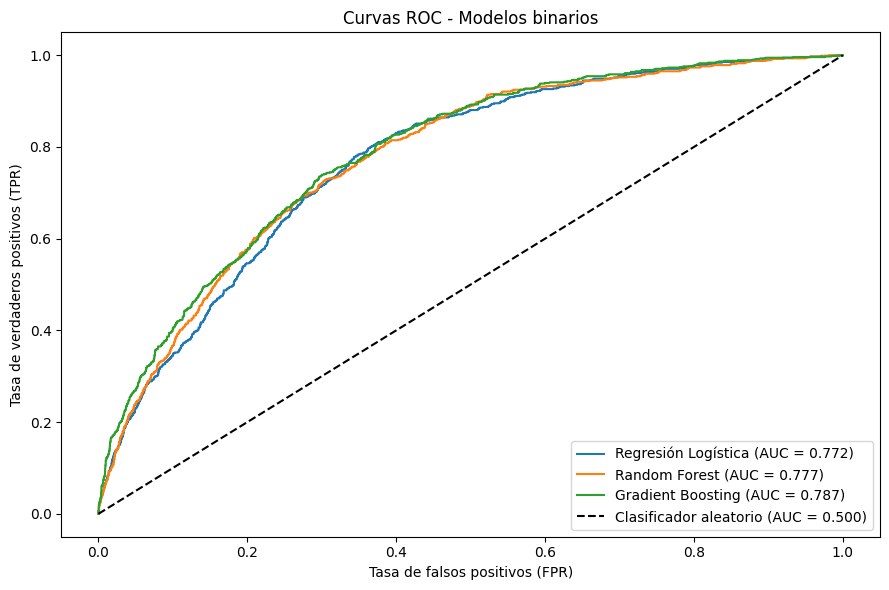


=== AUC POR MODELO ===
                Modelo     AUC
2    Gradient Boosting  0.7871
1        Random Forest  0.7774
0  Regresión Logística  0.7717


In [ ]:
# =========================================================
# 44B. CURVAS ROC Y AUC - MODELOS BINARIOS
# =========================================================
# La curva ROC mide la capacidad del modelo de distinguir entre
# la clase positiva (orientación sostenible alta) y la negativa.
# AUC = 1 es perfecto, AUC = 0.5 equivale a predecir al azar.

from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(9, 6))

modelos_roc = {
    "Regresión Logística": (log_model_bin, X_test_bin_scaled),
    "Random Forest":       (rf_model_bin,  X_test_bin),
    "Gradient Boosting":   (gb_model_bin,  X_test_bin),
}

resultados_auc = []

for nombre, (modelo, X_test_roc) in modelos_roc.items():
    y_prob = modelo.predict_proba(X_test_roc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_bin, y_prob)
    roc_auc = auc(fpr, tpr)
    resultados_auc.append({"Modelo": nombre, "AUC": round(roc_auc, 4)})
    plt.plot(fpr, tpr, label=f"{nombre} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Clasificador aleatorio (AUC = 0.500)')
plt.title("Curvas ROC - Modelos binarios")
plt.xlabel("Tasa de falsos positivos (FPR)")
plt.ylabel("Tasa de verdaderos positivos (TPR)")
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f"{output_dir}/curvas_roc_binarias.png", bbox_inches="tight")
plt.show()

tabla_auc = pd.DataFrame(resultados_auc).sort_values("AUC", ascending=False)
print("\n=== AUC POR MODELO ===")
print(tabla_auc)
tabla_auc.to_csv(f"{output_dir}/tabla_auc_binarios.csv", index=False)

In [ ]:
# =========================================================
# 45. GUARDAR DATASETS Y TABLAS
# =========================================================

df.to_csv(f"{output_dir}/dataset_limpio.csv", index=False)
df_model.to_csv(f"{output_dir}/dataset_modelado.csv", index=False)

if 'tabla_pct' in globals():
    tabla_pct.to_csv(f"{output_dir}/tabla_nivel_educativo.csv")

tabla_sexo_pct.to_csv(f"{output_dir}/tabla_sexo.csv")
tabla_precio.to_csv(f"{output_dir}/tabla_precio.csv")
tabla_eco.to_csv(f"{output_dir}/tabla_eco.csv")
tabla_confianza.to_csv(f"{output_dir}/tabla_confianza.csv")
df_importancia_rf.to_csv(f"{output_dir}/importancia_random_forest.csv", index=False)
df_importancia_gb.to_csv(f"{output_dir}/importancia_gradient_boosting.csv", index=False)

print("\nArchivos generados:")
print(os.listdir(output_dir))


Archivos generados:
['grafico_nivel_educativo_bonito.png', 'distribucion_sostenibilidad_bonita.png', 'matriz_correlacion.png', 'confusion_gradient_boosting.png', 'tabla_comparativa_modelos_binarios.csv', 'grafico_paises_top10_muestra.png', 'arbol_decision_legible.png', 'grafico_confianza_empresas_bonito.png', 'grafico_pais_bonito_ordenado.png', 'tabla_precio.csv', 'reglas_arbol.txt', 'nulos_tras_limpieza.png', 'grafico_factores_compra_bonito.png', 'importancia_random_forest.csv', 'media_sostenibilidad_pais.png', 'dataset_limpio.csv', 'tabla_comparativa_modelos.csv', 'curvas_roc_binarias.png', 'grafico_comparativo_modelos.png', 'grafico_ecoetiquetas_bonito.png', 'importancia_gradient_boosting.png', 'boxplot_edad_sostenibilidad.png', 'dataset_modelado.csv', 'histograma_edad.png', 'tabla_nivel_educativo.csv', 'importancia_gradient_boosting.csv', 'confusion_random_forest.png', 'tabla_auc_binarios.csv', 'tabla_eco.csv', 'tabla_resumen_paises.csv', 'tabla_sexo.csv', 'tabla_confianza.csv', '

In [ ]:
# =========================================================
# 46. DESCARGAR UN ARCHIVO CONCRETO
# =========================================================

files.download(f"{output_dir}/tabla_comparativa_modelos.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>